In [1]:
# Görev 1:
    # Karpathy'nin İngilizce names.txt dosyasıyla başla
    # Bigram'ları
        # önce Python dictionary ile say
        # sonra 27x27 torch tensor'da say. 
    # Tabloyu videodaki gibi görselleştir



words = open('names.txt', 'r').read().splitlines()


# .txt ye eda yapıyoruz
words_len = len(words)

min_length = min(len(word) for word in words)
min_length_word = [word for word in words if len(word) == min_length]

max_length = max(len(word) for word in words)
max_length_word = [word for word in words if len(word) == max_length]


print(f"total kelime sayısı: {words_len}\n\n\n")

print(f"En KISA kelimeler: {min_length_word}\n\n")

print(f"En UZUN kelimeler: {max_length_word}\nuzunluk: {max_length}\n\n\n\n")






# bigram nasıl çalışır?  - adım adım gösterim
count = {}
print("\nBigram Nasıl Çalışır - 3 Örnek Üzerinden\n")
for word in words[:3]:
    chars = ['<S>'] + list(word) + ['<E>']
    print(f"Kelime: {word}  -  char'lar: {chars}")
    for ch1, ch2 in zip(chars[:], chars[1:]):
        bigram = (ch1, ch2)
        count[bigram] = count.get(bigram, 0) + 1

        print(ch1, ch2)
    print("\n")







# bigram pair'ların miktarlarını tutmak


## 1) dictionary ile tutmak
for word in words:
    chars = ['<S>'] + list(word) + ['<E>']
    for ch1, ch2 in zip(chars[:], chars[1:]):
        bigram = (ch1, ch2)
        count[bigram] = count.get(bigram, 0) + 1
print("\n\n----- Python Dictionary ile -----")
print(f"En yaygın pair'lar: {sorted(count.items(), key = lambda kv: -kv[1])}")


## 2) pytorch ile tutmak
import torch

print("\n\n-----  Pytorch Tensors ile  -----")

chars = sorted(list(set(''.join(words))))
chars_len = len(chars)

print(f"Kaç tane char var: {chars_len}\nchar'lar: {chars}")


### ilkel yol:
N_eski = torch.zeros((28,28), dtype=torch.int32)
    # => neden 28 x 28 ? (neden 26 değil?)
    ## (İngilizce) alfabede 26 harf var + "start token <S>" + "end token <E>"

string_index_map_eski = {s:i for i,s in enumerate(chars)}
string_index_map_eski['<S>'] = 26
string_index_map_eski['<E>'] = 27

for word in words:
    chs = ["<S>"] + list(word) + ["<E>"]

    for ch1, ch2 in zip(chs[:], chs[1:]):
        index1 = string_index_map_eski.get(ch1)
        index2 = string_index_map_eski.get(ch2)
        N_eski[index1, index2] += 1


### gelişmiş yol:
N = torch.zeros((27, 27), dtype=torch.int32)
    # <S> ve <E> yerine "." koyuyoruz


chars = sorted(list(set(''.join(words))))
stoi = {s: i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}

    # Karakter geçişlerini say
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1


total kelime sayısı: 32033



En KISA kelimeler: ['an', 'jo', 'bo', 'zo', 'vy', 'eh', 'vi', 'mi', 'io', 'kc', 'ty', 'fe', 'ma', 'my', 'sa', 'ky', 'lo', 'lu', 'mj', 'tu', 'xi', 'bo', 'ty', 'om', 'aj', 'cy', 'oz', 'jj', 'ky', 'an', 'rj', 'tj', 'md', 'jr', 'al', 'eh', 'cj', 'yi', 'kc', 'dj', 'mj', 'ra', 'jc', 'jd', 'kj', 'ed', 'sy', 'yu', 'ej', 'ry', 'jw', 'jp', 'jt', 'ki', 'lj', 'ao', 'do', 'jo', 'ku', 'vu', 'zo', 'zy', 'jb', 'la', 'qi']


En UZUN kelimeler: ['muhammadibrahim', 'muhammadmustafa']
uzunluk: 15





Bigram Nasıl Çalışır - 3 Örnek Üzerinden

Kelime: emma  -  char'lar: ['<S>', 'e', 'm', 'm', 'a', '<E>']
<S> e
e m
m m
m a
a <E>


Kelime: olivia  -  char'lar: ['<S>', 'o', 'l', 'i', 'v', 'i', 'a', '<E>']
<S> o
o l
l i
i v
v i
i a
a <E>


Kelime: ava  -  char'lar: ['<S>', 'a', 'v', 'a', '<E>']
<S> a
a v
v a
a <E>




----- Python Dictionary ile -----
En yaygın pair'lar: [(('n', '<E>'), 6763), (('a', '<E>'), 6643), (('a', 'n'), 5438), (('<S>', 'a'), 4411), (('e', '<E>'), 3983), ((

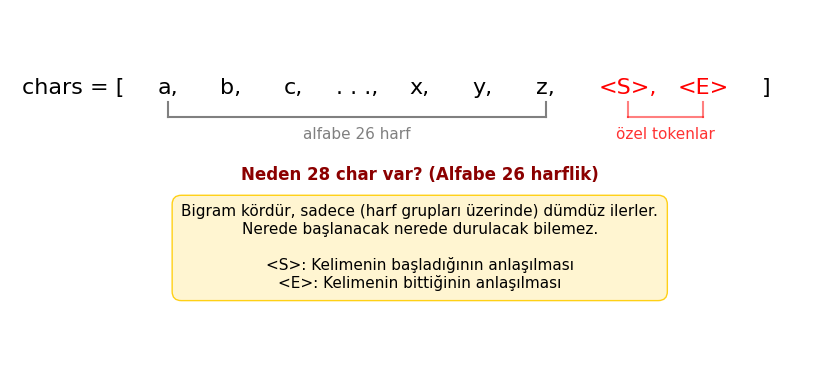

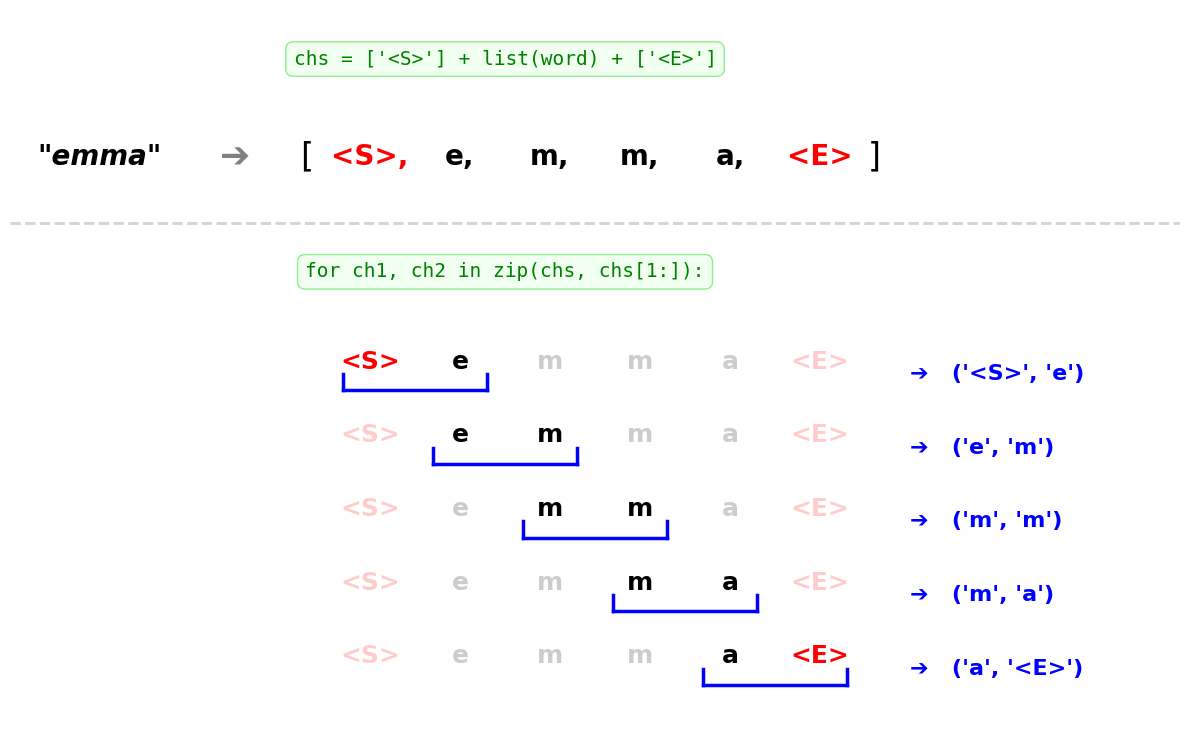

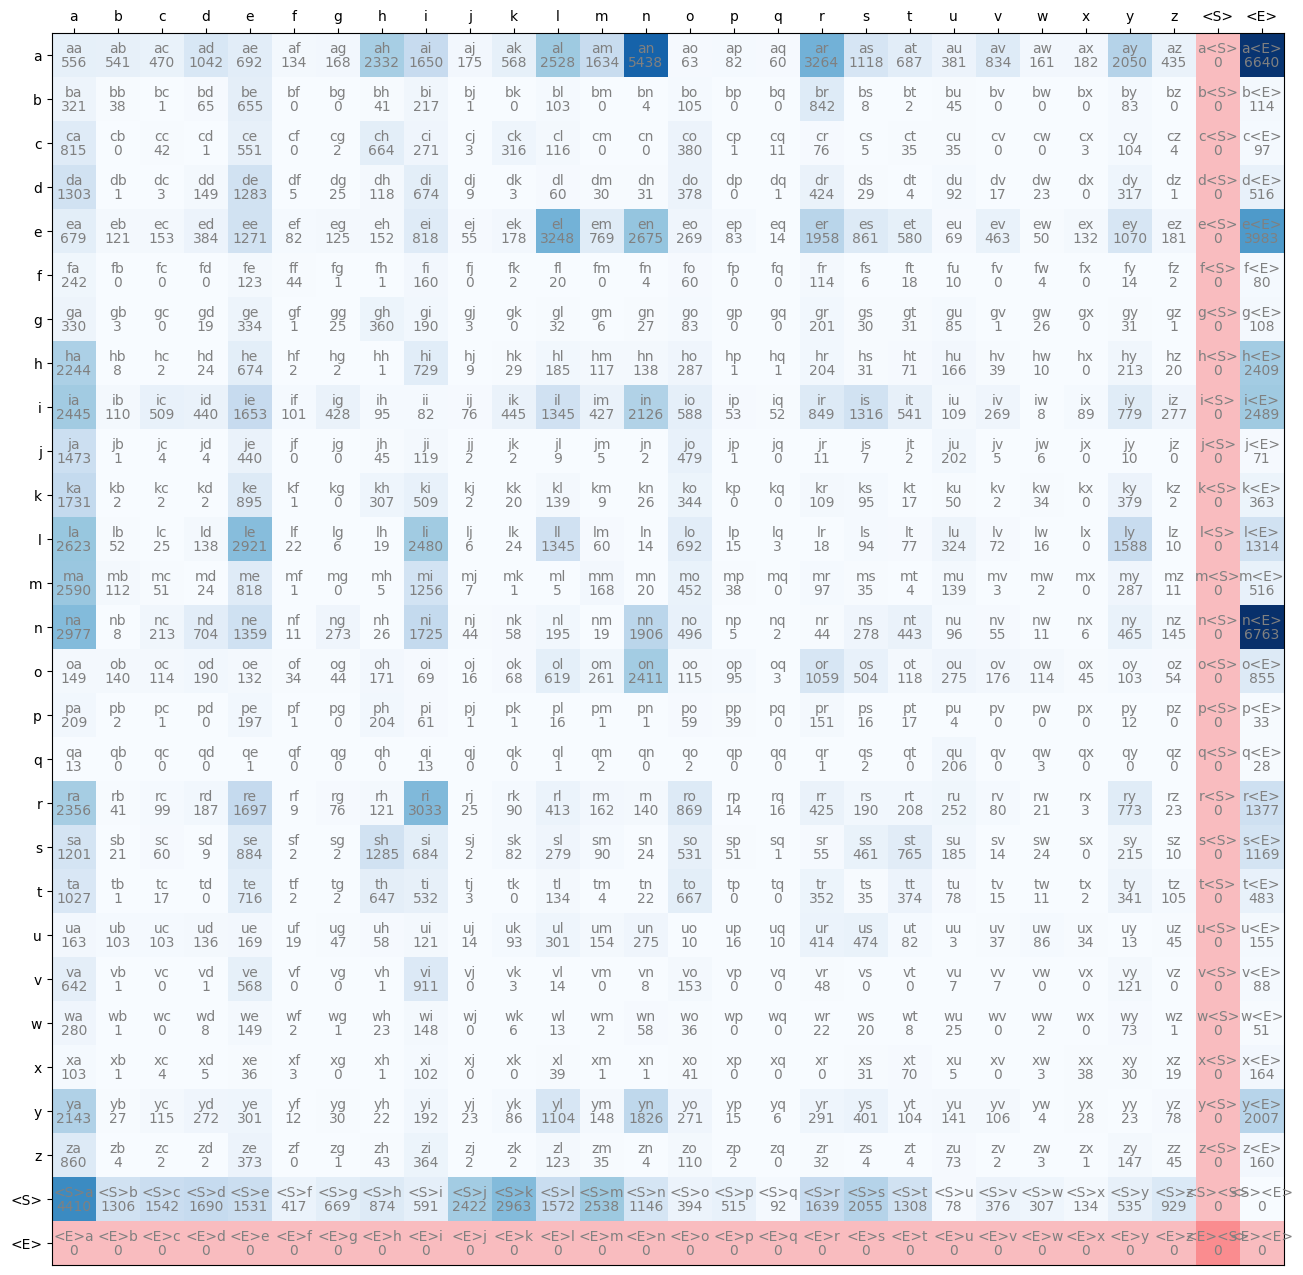

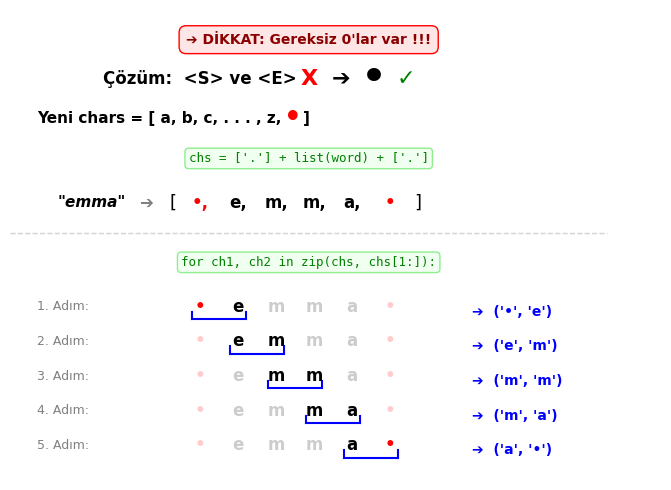

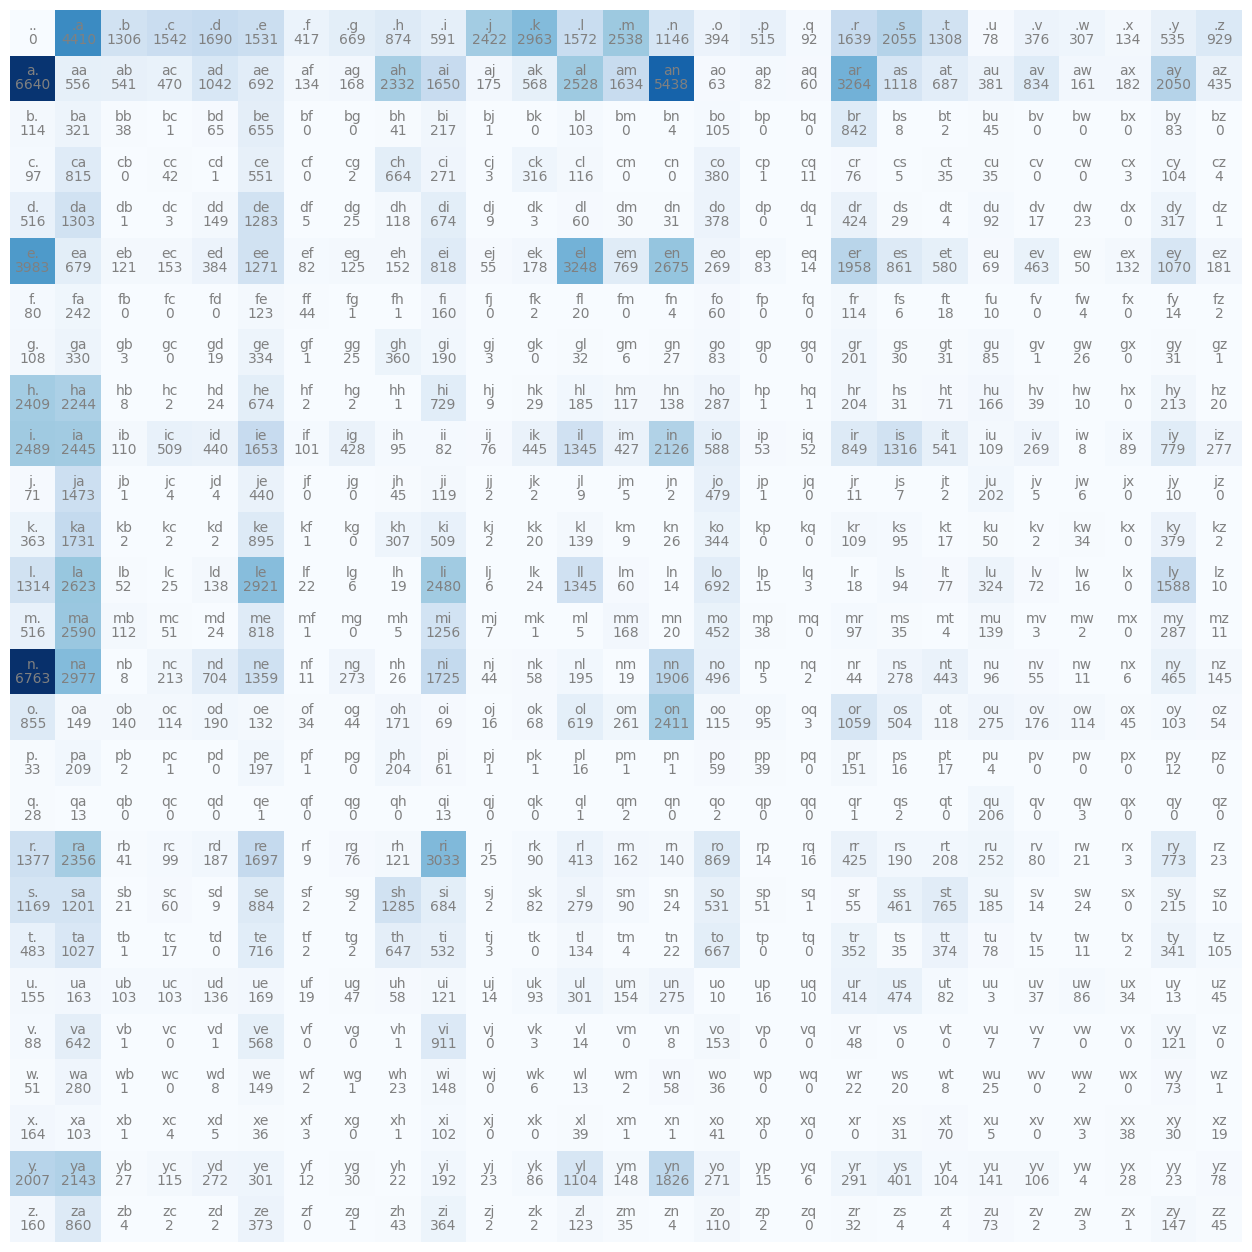

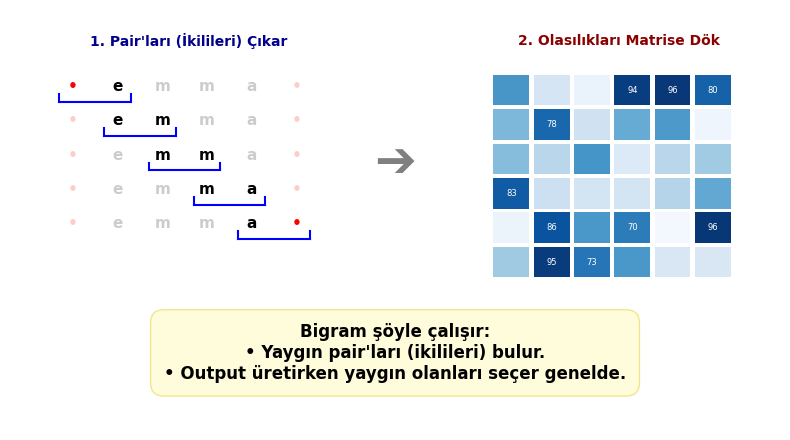

In [2]:
# görselleştirme
# ---------------- HARF KÜMESİ VE ÖZEL TOKENLAR İNFOGRAFİĞİ ----------------
import matplotlib.pyplot as plt

# Kutuların rahat sığması için yüksekliği çok hafif ayarladık
plt.figure(figsize=(8.5, 3.8))

plt.text(-1.5, 0, 'chars = [', ha='center', va='center', fontsize=16, color='black')

# 1) Harfler
chars_to_show = ['a,', 'b,', 'c,', '. . .,', 'x,', 'y,', 'z,']
for i, ch in enumerate(chars_to_show):
    plt.text(i, 0, ch, ha='center', va='center', fontsize=16)

# 2) Özel tokenlar
plt.text(7.3, 0, '<S>,', ha='center', va='center', fontsize=16, color='red')
plt.text(8.5, 0, '<E>', ha='center', va='center', fontsize=16, color='red')

plt.text(9.5, 0, ']', ha='center', va='center', fontsize=16, color='black')

# 4) Alfabe çizgisi
plt.plot([0, 6], [-0.3, -0.3], color='gray', lw=1.5) 
plt.plot([0, 0], [-0.3, -0.15], color='gray', lw=1.5) 
plt.plot([6, 6], [-0.3, -0.15], color='gray', lw=1.5) 
plt.text(3, -0.4, "alfabe 26 harf", ha='center', va='top', fontsize=11, color='gray')

# 5) Özel token çizgisi
plt.plot([7.3, 8.5], [-0.3, -0.3], color='red', lw=1.5, alpha=0.5)
plt.plot([7.3, 7.3], [-0.3, -0.15], color='red', lw=1.5, alpha=0.5)
plt.plot([8.5, 8.5], [-0.3, -0.15], color='red', lw=1.5, alpha=0.5)
plt.text(7.9, -0.4, "özel tokenlar", ha='center', va='top', fontsize=11, color='red', alpha=0.8)

# 6) Soru 
plt.text(4, -0.9, "Neden 28 char var? (Alfabe 26 harflik)", ha='center', va='center', fontsize=12, fontweight='bold', color='darkred')

# 7) Alt Sarı Kutu (multialignment eklendi)
aciklama_alt = (
    "Bigram kördür, sadece (harf grupları üzerinde) dümdüz ilerler.\n"
    "Nerede başlanacak nerede durulacak bilemez.\n\n"
    "<S>: Kelimenin başladığının anlaşılması\n"
    "<E>: Kelimenin bittiğinin anlaşılması"
)
plt.text(4, -1.2, aciklama_alt, ha='center', va='top', multialignment='center', fontsize=11, color='black', 
         bbox=dict(facecolor='#fff4cc', edgecolor='#ffcc00', boxstyle='round,pad=0.6', alpha=0.9))

# Eksen ayarları (Simetri için xlim ve ylim düzeltildi)
plt.axis('off')
plt.xlim(-2.5, 10.5)
plt.ylim(-2.8, 0.8)
plt.tight_layout()
plt.show()
# --------------------------------------------------------------------------


# ---------------- KELİME PARÇALAMA VE BIGRAM ÇIKARIMI İNFOGRAFİĞİ ----------------
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7.5))

# --- ÜST KISIM: 1. SATIRIN KODU VE ÇALIŞMASI ---
# İlgili kod satırı
kod_1 = "chs = ['<S>'] + list(word) + ['<E>']"
plt.text(5.5, 7.2, kod_1, ha='center', va='center', fontsize=14, color='green', fontfamily='monospace', 
         bbox=dict(facecolor='#f0fff0', edgecolor='lightgreen', boxstyle='round,pad=0.4'))

# "emma" yazısı ve ok işareti
plt.text(1, 6, '"emma"', ha='center', va='center', fontsize=20, fontweight='bold', fontstyle='italic')
plt.text(2.5, 6, '➔', ha='center', va='center', fontsize=26, color='gray')

# Parçalanmış ve aralarına boşluk konmuş liste hali
chars = ['<S>', 'e', 'm', 'm', 'a', '<E>']
x_coords = [4, 5, 6, 7, 8, 9] # Harfler arası geniş boşluklar var

plt.text(3.3, 6, '[', ha='center', va='center', fontsize=24)
for i, (ch, x) in enumerate(zip(chars, x_coords)):
    color = 'red' if ch in ['<S>', '<E>'] else 'black'
    # Liste olduğunu vurgulamak için virgül koyuyoruz (son harf hariç)
    text_str = ch if i == len(chars)-1 else ch + ','
    plt.text(x, 6, text_str, ha='center', va='center', fontsize=20, color=color, fontweight='bold')
plt.text(9.6, 6, ']', ha='center', va='center', fontsize=24)

# Ayıraç çizgisi
plt.plot([0, 13], [5.2, 5.2], color='lightgray', lw=2, linestyle='--')

# --- ALT KISIM: 2. SATIRIN KODU VE ÇALIŞMASI (KAYAN PENCERE) ---
# İlgili kod satırı
kod_2 = "for ch1, ch2 in zip(chs, chs[1:]):"
plt.text(5.5, 4.6, kod_2, ha='center', va='center', fontsize=14, color='green', fontfamily='monospace', 
         bbox=dict(facecolor='#f0fff0', edgecolor='lightgreen', boxstyle='round,pad=0.4'))

# Adım Adım Bigram Çıkarımı
for step in range(5):
    y_base = 3.5 - step * 0.9  # Her adımda bir alt satıra iniyoruz
    
    # Sol tarafa Adım yazısı
    
    # Harflerin çizimi (Kutunun içindekiler net, dışındakiler soluk gözükecek)
    for i, (ch, x) in enumerate(zip(chars, x_coords)):
        color = 'red' if ch in ['<S>', '<E>'] else 'black'
        # Eğer harf şu anki ikilinin (bigram) içindeyse alfa=1 (net), değilse alfa=0.2 (soluk)
        alpha = 1.0 if (i == step or i == step+1) else 0.2
        plt.text(x, y_base, ch, ha='center', va='center', fontsize=18, color=color, fontweight='bold', alpha=alpha)
        
    # Alt Çizgi Kutusu (Bracket) |_|
    x_left = x_coords[step]
    x_right = x_coords[step+1]
    
    plt.plot([x_left - 0.3, x_right + 0.3], [y_base - 0.35, y_base - 0.35], color='blue', lw=2.5) # Yatay alt çizgi
    plt.plot([x_left - 0.3, x_left - 0.3], [y_base - 0.35, y_base - 0.15], color='blue', lw=2.5) # Sol dik çizgi
    plt.plot([x_right + 0.3, x_right + 0.3], [y_base - 0.35, y_base - 0.15], color='blue', lw=2.5) # Sağ dik çizgi
    
    # Çıkan Bigram'ı sağ tarafta gösterelim
    bigram_str = f"➔   ('{chars[step]}', '{chars[step+1]}')"
    plt.text(10, y_base - 0.15, bigram_str, ha='left', va='center', fontsize=16, fontweight='bold', color='blue')

# Eksen ayarları
plt.axis('off')
plt.xlim(0, 13)
plt.ylim(-1.0, 7.8)
plt.tight_layout()
plt.show()
# --------------------------------------------------------------------------


import matplotlib.pyplot as plt
import matplotlib.patches as patches # Dikdörtgen çizmek için ekledik

index_string_map_eski = {i: s for s, i in string_index_map_eski.items()}

plt.figure(figsize=(16, 16))
plt.imshow(N_eski, cmap='Blues')

# 0'dan 27'ye kadar olan indexler için ilgili harfleri listeye çeviriyoruz
ticks_eski = list(range(28))
labels_eski = [index_string_map_eski[i] for i in ticks_eski]

# X ve Y eksenlerine harfleri yerleştiriyoruz
plt.xticks(ticks_eski, labels_eski)
plt.yticks(ticks_eski, labels_eski)

# X eksenindeki harfleri grafiğin üst kısmına almak genelde daha güzel durur
ax = plt.gca()
ax.xaxis.tick_top()

# ----------------- KIRMIZI VURGU KISMI -----------------
s_index_eski = string_index_map_eski['<S>']
e_index_eski = string_index_map_eski['<E>']

# <S>'nin bulunduğu SÜTUNU (j, X ekseni) kırmızı yapıyoruz
# X=s_index - 0.5'ten başlayıp, Genişlik=1, Yükseklik=28 olan bir kutu
rect_s_eski = patches.Rectangle((s_index_eski - 0.5, -0.5), 1, 28, linewidth=0, facecolor='red', alpha=0.25)
ax.add_patch(rect_s_eski)

# <E>'nin bulunduğu SATIRI (i, Y ekseni) kırmızı yapıyoruz
# Y=e_index - 0.5'ten başlayıp, Genişlik=28, Yükseklik=1 olan bir kutu
rect_e_eski = patches.Rectangle((-0.5, e_index_eski - 0.5), 28, 1, linewidth=0, facecolor='red', alpha=0.25)
ax.add_patch(rect_e_eski)
# -------------------------------------------------------

for i in range(28):
    for j in range(28):
        chstr = index_string_map_eski[i] + index_string_map_eski[j]
        plt.text(j, i, chstr, ha='center', va='bottom', color='gray')
        plt.text(j, i, N_eski[i, j].item(), ha='center', va='top', color='gray')

plt.show()


# ---------------- NOKTA (.) KULLANIMINA GEÇİŞ (MİNİ İNFOGRAFİK) ----------------
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5.0)) 

# --- EN ÜSTTEKİ UYARI KUTUSU (SADECE UYARI) ---
title_text = "➔ DİKKAT: Gereksiz 0'lar var !!!"
plt.text(5.5, 8.4, title_text, ha='center', va='center', fontsize=10, color='darkred', fontweight='bold',
         bbox=dict(facecolor='#ffe6e6', edgecolor='red', boxstyle='round,pad=0.5'))

# --- ÇÖZÜM KISMI (Hizalamalar ve aralıklar düzeltildi, nokta dairesel (•) oldu) ---
y_hiza = 7.6
# Metni tek parça yazdık ve merkeze aldık ki x ile çakışmasın
plt.text(3.5, y_hiza, "Çözüm:  <S> ve <E>", ha='center', va='center', fontsize=12, fontweight='bold')
plt.text(5.5, y_hiza, "X", ha='center', va='center', fontsize=16, color='red', fontweight='bold')
plt.text(6.1, y_hiza, "➔", ha='center', va='center', fontsize=16, fontweight='bold')
# Kare olmayan, dairesel nokta (bullet)
plt.text(6.7, y_hiza, "•", ha='center', va='center', fontsize=34, color='black') 
plt.text(7.3, y_hiza, "✓", ha='center', va='center', fontsize=16, color='green', fontweight='bold')

# --- Yeni chars YAZISI (Dairesel nokta) ---
plt.text(5.0, 6.8, "Yeni chars = [ a, b, c, . . . , z,", ha='right', va='center', fontsize=11, fontweight='bold')
plt.text(5.2, 6.8, "•", ha='center', va='center', fontsize=24, color='red')
plt.text(5.4, 6.8, "]", ha='left', va='center', fontsize=11, fontweight='bold')

# --- 1. SATIRIN KODU ---
kod_1 = "chs = ['.'] + list(word) + ['.']"
plt.text(5.5, 6.0, kod_1, ha='center', va='center', fontsize=9, color='green', fontfamily='monospace', 
         bbox=dict(facecolor='#f0fff0', edgecolor='lightgreen', boxstyle='round,pad=0.3'))

# "emma" yazısı ve liste
plt.text(1.5, 5.1, '"emma"', ha='center', va='center', fontsize=11, fontweight='bold', fontstyle='italic')
plt.text(2.5, 5.1, '➔', ha='center', va='center', fontsize=12, color='gray')

# Listede de dairesel (bullet) kullanalım (gerçek koddaki gibi)
chars = ['•', 'e', 'm', 'm', 'a', '•']
x_coords = [3.5, 4.2, 4.9, 5.6, 6.3, 7.0]

plt.text(3, 5.1, '[', ha='center', va='center', fontsize=13)
for i, (ch, x) in enumerate(zip(chars, x_coords)):
    color = 'red' if ch == '•' else 'black'
    text_str = ch if i == len(chars)-1 else ch + ','
    plt.text(x, 5.1, text_str, ha='center', va='center', fontsize=12, color=color, fontweight='bold')
plt.text(7.5, 5.1, ']', ha='center', va='center', fontsize=13)

# Ayıraç çizgisi
plt.plot([0, 11], [4.5, 4.5], color='lightgray', lw=1, linestyle='--')

# --- 2. SATIRIN KODU (KAYAN PENCERE) ---
kod_2 = "for ch1, ch2 in zip(chs, chs[1:]):"
plt.text(5.5, 3.9, kod_2, ha='center', va='center', fontsize=9, color='green', fontfamily='monospace', 
         bbox=dict(facecolor='#f0fff0', edgecolor='lightgreen', boxstyle='round,pad=0.3'))

for step in range(5):
    y_base = 3.0 - step * 0.7 
    
    plt.text(0.5, y_base, f"{step+1}. Adım:", ha='left', va='center', fontsize=9, color='gray')
    
    for i, (ch, x) in enumerate(zip(chars, x_coords)):
        color = 'red' if ch == '•' else 'black'
        alpha = 1.0 if (i == step or i == step+1) else 0.2
        plt.text(x, y_base, ch, ha='center', va='center', fontsize=12, color=color, fontweight='bold', alpha=alpha)
        
    x_left = x_coords[step]
    x_right = x_coords[step+1]
    
    # Minik köşeli parantez
    plt.plot([x_left - 0.15, x_right + 0.15], [y_base - 0.25, y_base - 0.25], color='blue', lw=1.5)
    plt.plot([x_left - 0.15, x_left - 0.15], [y_base - 0.25, y_base - 0.1], color='blue', lw=1.5)
    plt.plot([x_right + 0.15, x_right + 0.15], [y_base - 0.25, y_base - 0.1], color='blue', lw=1.5)
    
    # '•' olarak gösteriyoruz
    bigram_str = f"➔  ('{chars[step]}', '{chars[step+1]}')"
    plt.text(8.5, y_base - 0.1, bigram_str, ha='left', va='center', fontsize=10, fontweight='bold', color='blue')

plt.axis('off')
plt.xlim(0, 12)
# 5. Adımın mavi çizgisinin kesilmemesi için Y ekseninin alt sınırını 0'dan -0.5'e indirdik!
plt.ylim(-0.5, 9.0) 
plt.tight_layout()
plt.show()
# -----------------------------------------------------------------------------------------------



plt.figure(figsize=(16, 16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off')

# ---------------- BİGRAMIN AMACI ÖZET (SON RESİM) ----------------
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

plt.figure(figsize=(8, 4.5))
ax = plt.gca()

# --- RESİM 1: MİNİ KAYAN PENCERE (Pair'ların bulunması) ---
plt.text(2.0, 3.6, "1. Pair'ları (İkilileri) Çıkar", ha='center', va='center', fontsize=10, fontweight='bold', color='darkblue')

chars_mini = ['•', 'e', 'm', 'm', 'a', '•']
for step in range(5):
    y_b = 3.0 - step * 0.45
    for i, ch in enumerate(chars_mini):
        c = 'red' if ch == '•' else 'black'
        alpha = 1.0 if i in [step, step+1] else 0.2
        plt.text(0.7 + i*0.5, y_b, ch, ha='center', va='center', fontsize=11, color=c, alpha=alpha, fontweight='bold')
    
    # Minik Mavi Bracket
    xl = 0.7 + step*0.5 - 0.15
    xr = 0.7 + (step+1)*0.5 + 0.15
    plt.plot([xl, xr], [y_b-0.2, y_b-0.2], color='blue', lw=1.5)
    plt.plot([xl, xl], [y_b-0.2, y_b-0.1], color='blue', lw=1.5)
    plt.plot([xr, xr], [y_b-0.2, y_b-0.1], color='blue', lw=1.5)

# --- OK İŞARETİ (GEÇİŞ) ---
plt.text(4.3, 2.0, "➔", ha='center', va='center', fontsize=36, color='gray')

# --- RESİM 2: MİNİ MATRİS (Isı Haritası Konsepti) ---
plt.text(6.8, 3.6, "2. Olasılıkları Matrise Dök", ha='center', va='center', fontsize=10, fontweight='bold', color='darkred')

np.random.seed(42) # Her seferinde aynı desen (aynı rastgelelik) çıksın
cmap = plt.cm.Blues
for i in range(6):
    for j in range(6):
        val = np.random.rand()
        color = cmap(val)
        # Matris hücreleri (Aralarında minik boşluklar bırakarak çiziyoruz)
        rect = patches.Rectangle((5.4 + j*0.45, 0.5 + i*0.45), 0.4, 0.4, facecolor=color)
        ax.add_patch(rect)
        # Sadece rengi koyu olanlara (olasılığı yüksek olanlara) görünür görünmez minik sayılar ekleyelim
        if val > 0.7:
            plt.text(5.4 + j*0.45 + 0.2, 0.5 + i*0.45 + 0.2, str(int(val*100)), ha='center', va='center', fontsize=6, color='white')

# --- ALT KISIM: İSTEDİĞİNİZ AÇIKLAMA ---
aciklama = (
    "Bigram şöyle çalışır:\n"
    "• Yaygın pair'ları (ikilileri) bulur.\n"
    "• Output üretirken yaygın olanları seçer genelde."
)
plt.text(4.3, -0.1, aciklama, ha='center', va='top', fontsize=12, fontweight='bold',
         bbox=dict(facecolor='#fffcdc', edgecolor='#f0e68c', boxstyle='round,pad=0.8'))

# --- GRAFİK AYARLARI ---
plt.axis('off')
plt.xlim(0, 8.6)
plt.ylim(-1.5, 4.0) # Alt metin sığsın diye aşağıyı geniş tuttuk
plt.tight_layout()
plt.show()
# ---------------------------------------------------------------------------------


# fikirler:
# bigram nasıl çalışır resim
# kodumuz nası düzgün çalışıyo resim?
    ## neden chs = ["<S>"] + list(word) + ["<E>"] yaptık?
    ## neden zip(chs[:], chs[1:] yaptık? (zip neden? farklı uzunluklar neden? neden o "nasıl çalışır resime uyuyo")

In [3]:
# Görev 2:
    # Sayım tablosunu satır satır olasılıklara çevir ve modelden yeni isimler örnekle. 



# pair sayılarını olasılıklara çevirmek 
p = N[0].float()
p = p / p.sum()
display(p)



# sonraki seçilecek char sample etmek 
    ## (p olasılıklarına göre)
g = torch.Generator().manual_seed(2147483647)
idx = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
display(itos[idx])


# untrained model  VS  trained model
## untrained model 
    ### uniform distribution (her şeyin olasılığı eşit)
    ### random tahmin ediyor
print("\n\n--- Untrained Model ---\n")
for i in range(20):
    out = []
    ix = 0
    while True:
        p = torch.ones(27) / 27
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break

    print(''.join(out))

## trained model 
print("\n\n--- Trained Model ---\n")
    
# N+1 yaptık smoothing için
P = (N+1).float() 
P = P / P.sum(1, keepdim=True)

# sonraki char sampling
g = torch.Generator().manual_seed(2147483647)

for i in range(20):
    out = []
    ix = 0
    while True:
        # unoptimized yol:
        # p = N[ix].float()
        # p = p / p.sum()
            ## N[ix] yaparak, o char'ın satırındaki dağılımları aldık sadece
                ## Örnek:
                    ### a. dayız
                    ### a. satırına bakarım sadece
                        #### aa nın değer, ab nin değer, ... , az nin değer
                    ### b. daki değerlere bakmak gereksiz

        # optimized yol:
        p = P[ix]
            ## clever trick!
                ### ix=0 dedik... direkt P[ix] geçtik
                ### çünkü, . ile başlarız her zaman
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])

        # . gelirse <E> gelmiştir - bitir
        if ix == 0:
            break

    print(''.join(out))

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

'c'



--- Untrained Model ---

exzm.
zoglkurkicqzktyhwmvmzimjttainrlkfukzkktda.
sfcxvpubjtbhrmgotzx.
iczixqctvujkwptedogkkjemkmmsidguenkbvgynywftbspmhwcivgbvtahlvsu.
dsdxxblnwglhpyiw.
igwnjwrpfdwipkwzkm.
desu.
firmt.
gbiksjbquabsvoth.
kuysxqevhcmrbxmcwyhrrjenvxmvpfkmwmghfvjzxobomysox.
gbptjapxweegpfwhccfyzfvksiiqmvwbhmiwqmdgzqsamjhgamcxwmmk.
iswcxfmbalcslhy.
fpycvasvz.
bqzazeunschck.
wnkojuoxyvtvfiwksddugnkul.
fuwfcgjz.
abl.
j.
nuuutstofgqzubbo.
rdubpknhmd.


--- Trained Model ---

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.
da.
staiyaubrtthrigotai.
moliellavo.
ke.
teda.
ka.
emimmsade.
enkaviyny.
ftlspihinivenvorhlasu.
dsor.
br.
jol.
pen.
aisan.
ja.


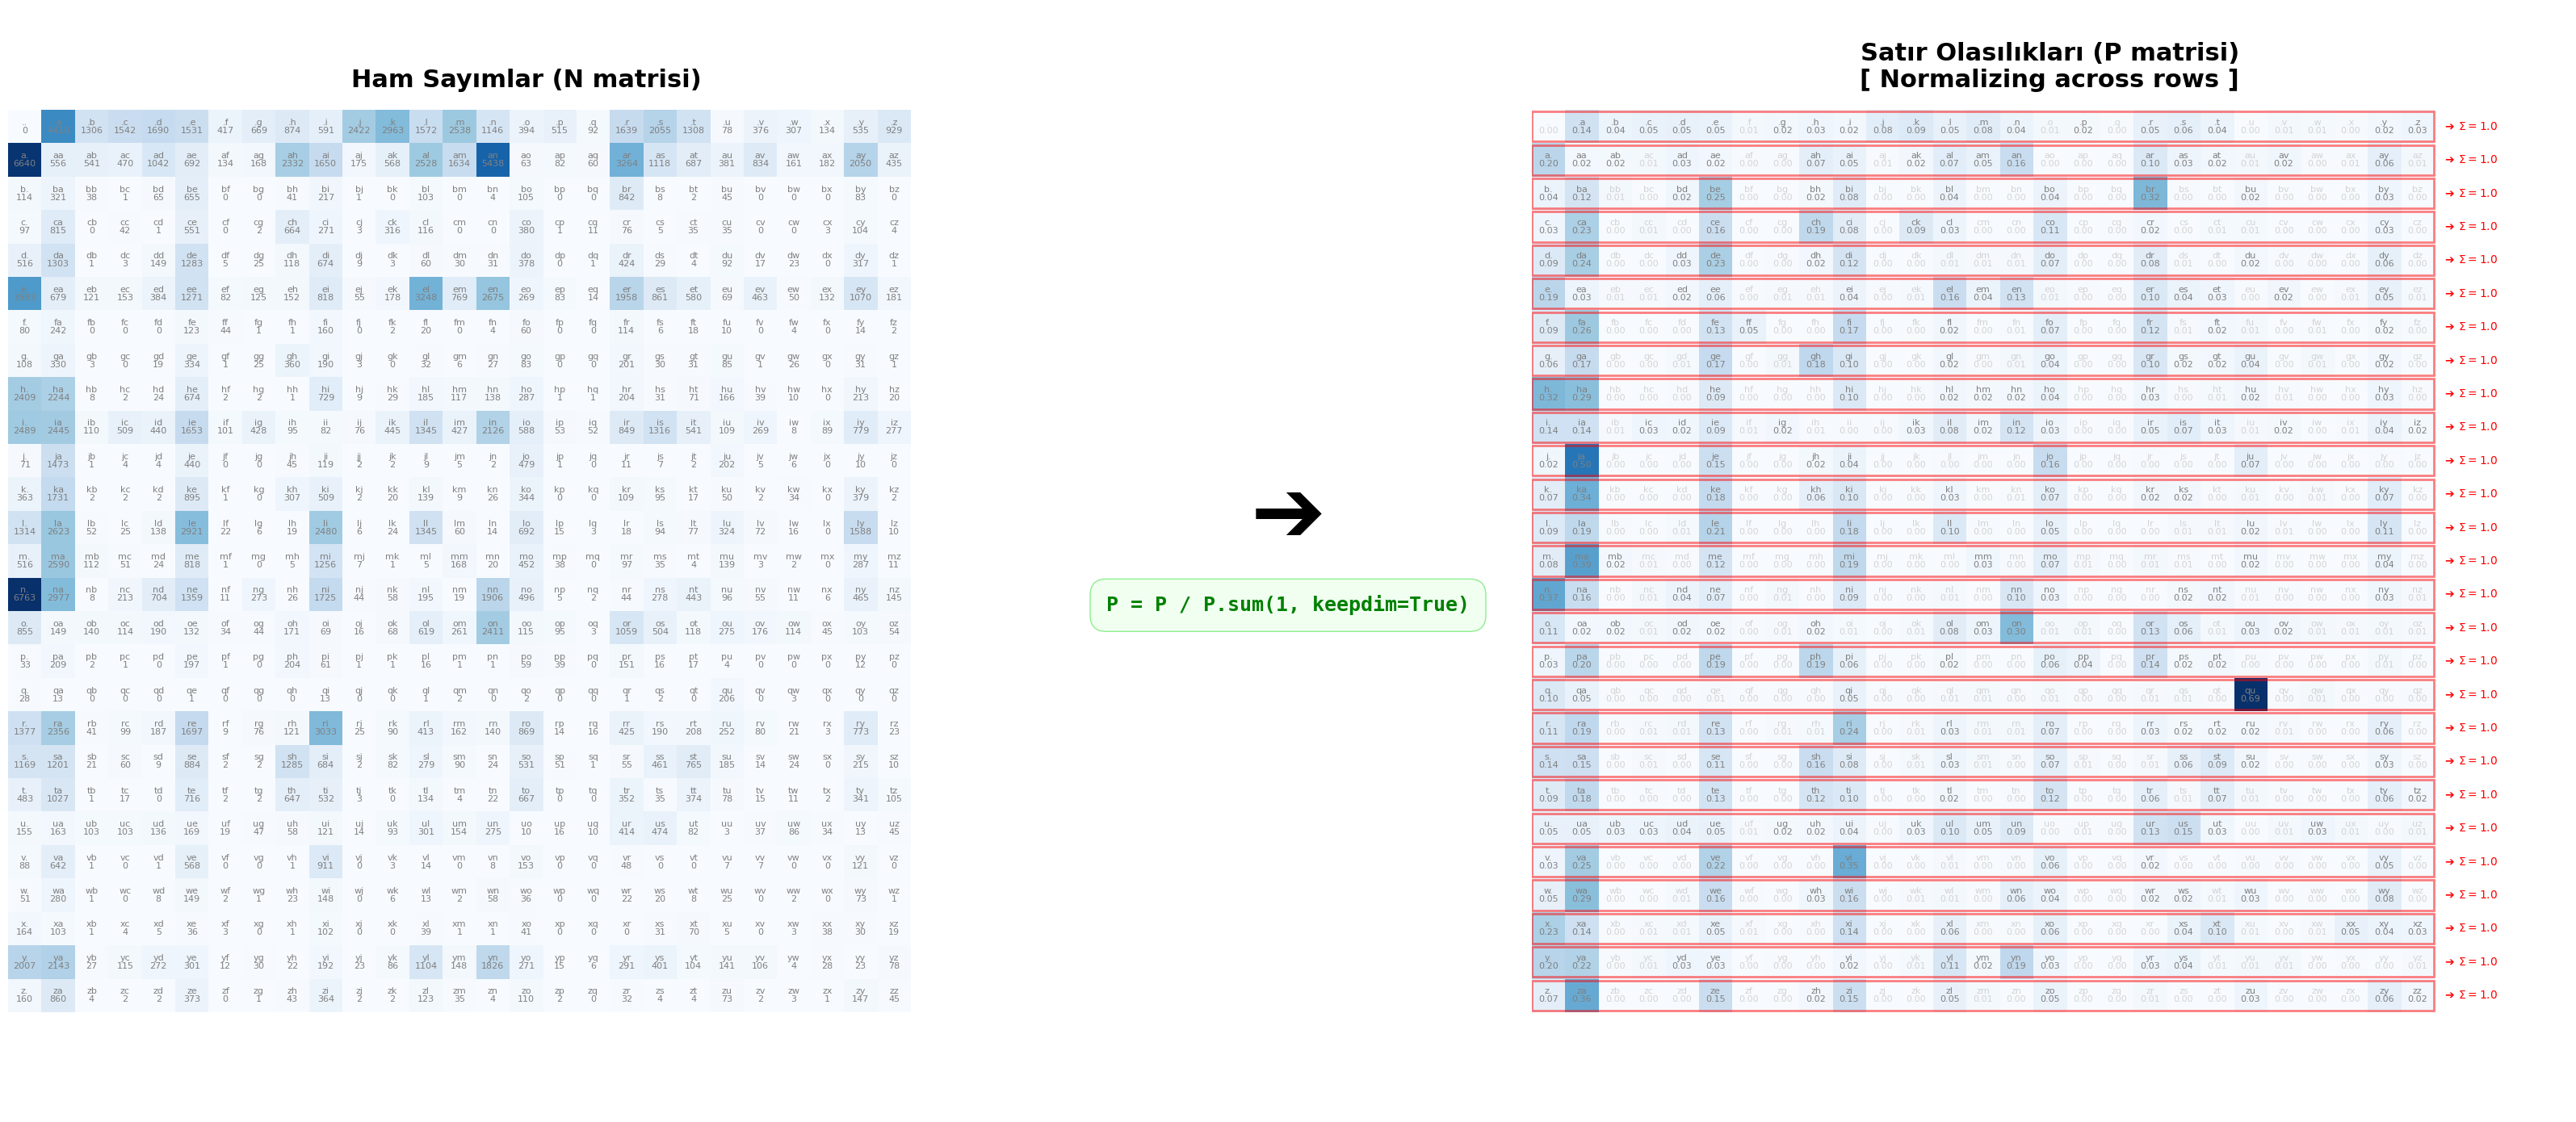

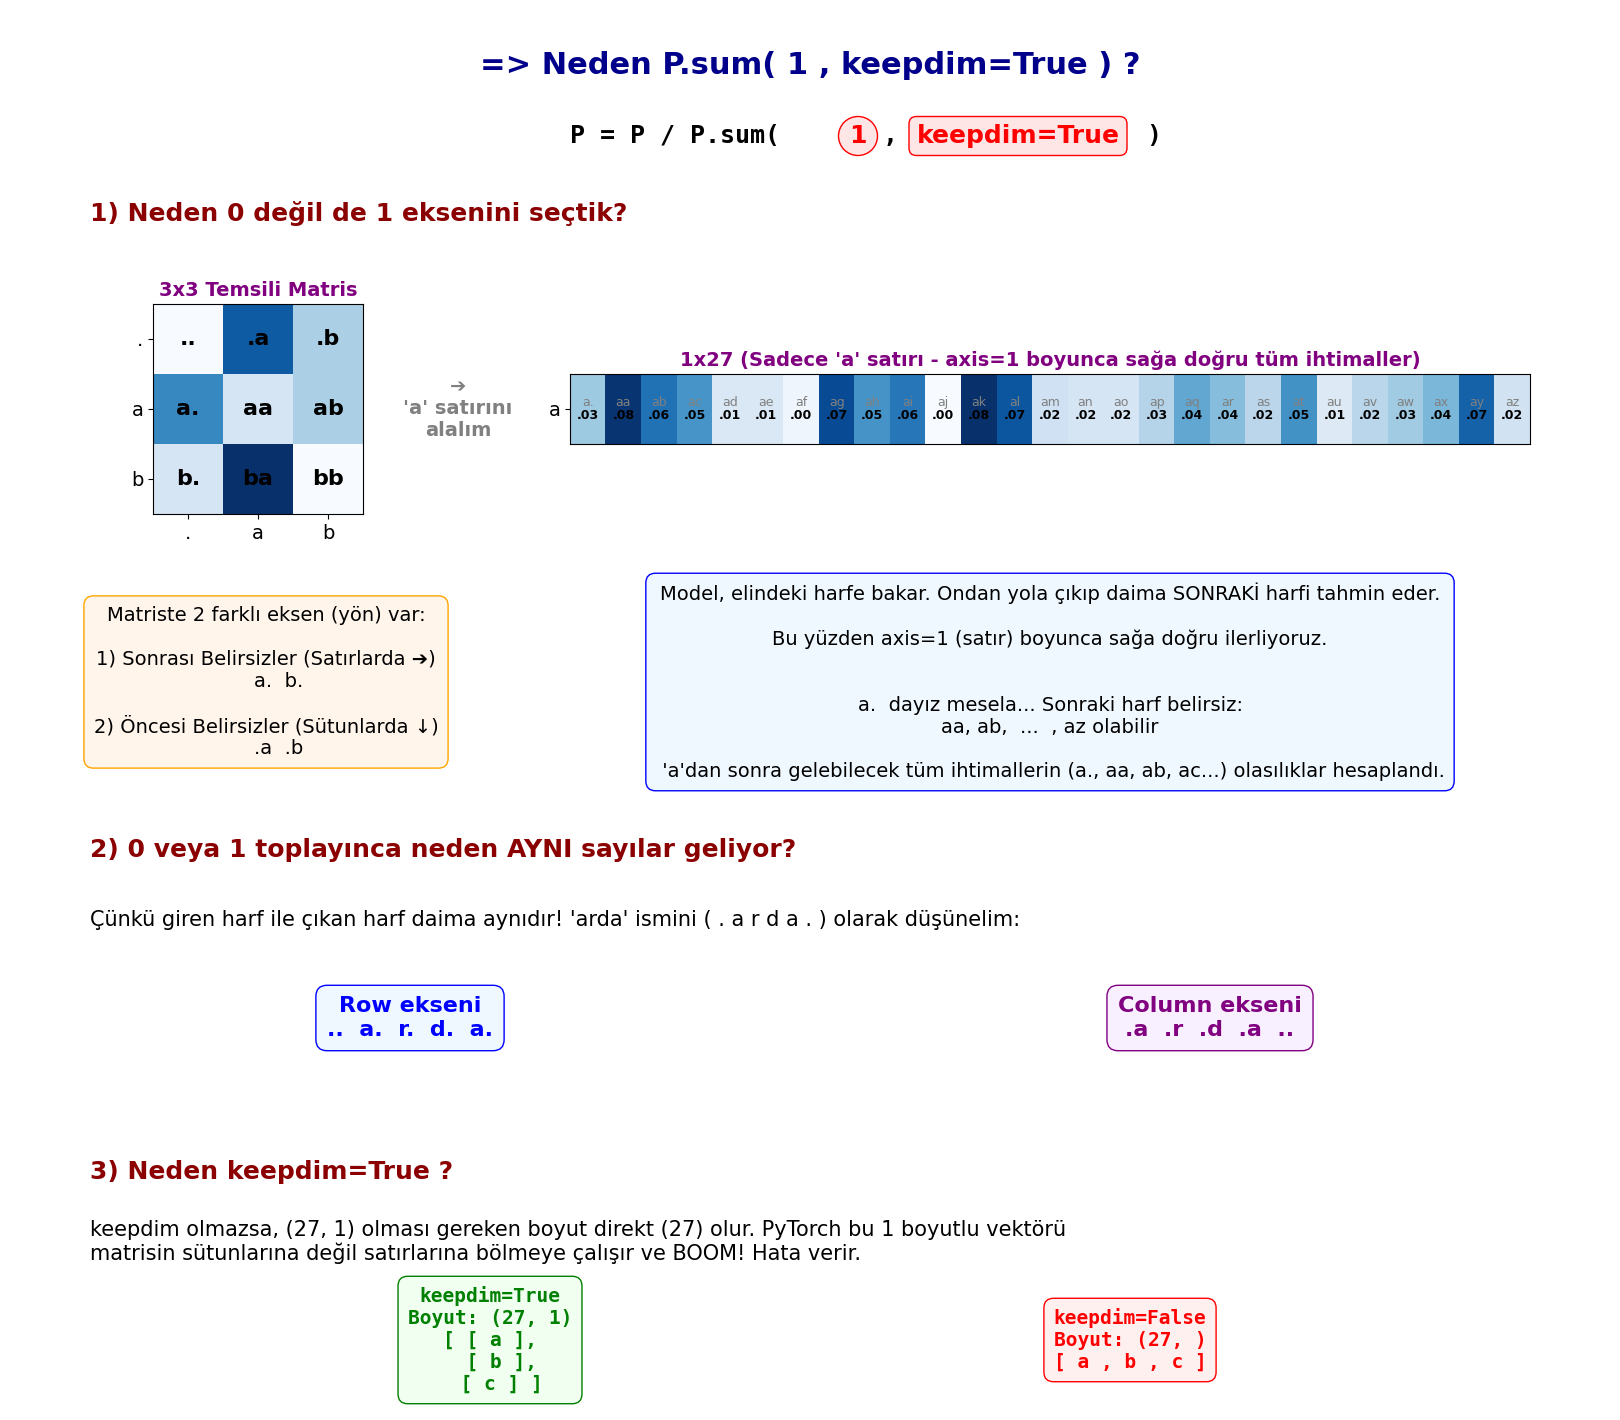

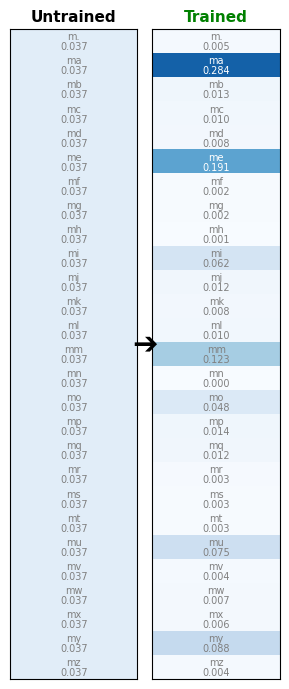

In [4]:
# görselleştirme
# ---------------- SATIR BAZLI OLASILIK (P = P / P.sum) İNFOGRAFİĞİ ----------------
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Modelinizin o anki N matrisinden P'yi tekrar hesaplıyoruz
P_gorsel = (N+1).float()
P_gorsel = P_gorsel / P_gorsel.sum(1, keepdim=True)

# 3'lü subplot yapısı: [Sol Matris] [Orta Boşluk (Ok+Yazı)] [Sağ Matris]
fig, axes = plt.subplots(1, 3, figsize=(32, 14), gridspec_kw={'width_ratios': [1, 0.35, 1]})

# --- SOL: COUNT (SAYIM) MATRİSİ ---
ax1 = axes[0]
ax1.imshow(N, cmap='Blues')
ax1.set_title("Ham Sayımlar (N matrisi)", fontsize=22, fontweight='bold', pad=20)

for i in range(27):
    # Sol tarafta kırmızı içine almıyoruz (İstediğiniz gibi sade bıraktık)
    for j in range(27):
        chstr = itos[i] + itos[j]
        val = N[i, j].item()
        ax1.text(j, i, chstr, ha="center", va="bottom", color='gray', fontsize=8)
        ax1.text(j, i, str(val), ha="center", va="top", color='gray', fontsize=8)

# --- ORTA: OK VE FORMÜL ---
ax_mid = axes[1]
ax_mid.axis('off') 

ax_mid.text(0.5, 0.54, '➔', ha='center', va='center', fontsize=80, color='black', fontweight='bold')
ax_mid.text(0.5, 0.46, 'P = P / P.sum(1, keepdim=True)', ha='center', va='center', fontsize=18, color='green', 
         fontfamily='monospace', fontweight='bold',
         bbox=dict(facecolor='#f0fff0', edgecolor='lightgreen', boxstyle='round,pad=0.8'))

# --- SAĞ: PROBABILITY (OLASILIK) MATRİSİ ---
ax2 = axes[2]
ax2.imshow(P_gorsel, cmap='Blues')
# Başlığa "Normalizing across rows" terimini ekledik
ax2.set_title("Satır Olasılıkları (P matrisi)\n[ Normalizing across rows ]", fontsize=22, fontweight='bold', pad=20)

for i in range(27):
    # Sadece burada her satırı yatay olarak kırmızı içine alıyoruz (Row-wise normalization'ı göstermek için)
    rect = patches.Rectangle((-0.5, i-0.45), 27, 0.9, fill=False, edgecolor='red', lw=2, alpha=0.5)
    ax2.add_patch(rect)
    
    # Satırların toplamının 1 olduğunu gösteren etiket
    ax2.text(26.7, i, " ➔ $\Sigma=1.0$", ha="left", va="center", color='red', fontsize=10, fontweight='bold')
    
    for j in range(27):
        chstr = itos[i] + itos[j]
        val_str = f"{P_gorsel[i, j].item():.2f}"
        
        c = 'gray'
        if val_str == "0.00" or val_str == "0.01":
            c = 'lightgray'
            
        ax2.text(j, i, chstr, ha="center", va="bottom", color=c, fontsize=8)
        ax2.text(j, i, val_str, ha="center", va="top", color=c, fontsize=8)

# Her iki matris grafiğinin eksenini eşit büyütüp sağda boşluk bırakıyoruz
for ax in [ax1, ax2]:
    ax.set_xlim(-0.5, 30.5) 
    ax.set_ylim(26.5, -0.5) 
    ax.axis('off')

plt.tight_layout()
plt.show()
# ------------------------------------------------------------------------------------------------


# ---------------- NEDEN 1 VE KEEPDIM İNFOGRAFİĞİ (GELİŞTİRİLMİŞ) ----------------
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure(figsize=(16, 14))
ax_main = fig.add_axes([0, 0, 1, 1])
ax_main.axis('off')

# --- BAŞLIK ---
ax_main.text(0.5, 0.96, "=> Neden P.sum( 1 , keepdim=True ) ?", ha='center', va='center', fontsize=22, fontweight='bold', color='darkblue')

# --- FORMÜL VE KIRMIZI VURGULAR ---
ax_main.text(0.35, 0.91, "P = P / P.sum(", ha='left', va='center', fontsize=18, fontfamily='monospace', fontweight='bold')
ax_main.text(0.53, 0.91, "1", ha='center', va='center', fontsize=18, color='red', fontweight='bold', bbox=dict(boxstyle='circle', facecolor='#ffe6e6', edgecolor='red', pad=0.3))
ax_main.text(0.55, 0.91, ",", ha='center', va='center', fontsize=18, fontfamily='monospace', fontweight='bold')
ax_main.text(0.63, 0.91, "keepdim=True", ha='center', va='center', fontsize=18, color='red', fontweight='bold', bbox=dict(boxstyle='round', facecolor='#ffe6e6', edgecolor='red', pad=0.3))
ax_main.text(0.71, 0.91, ")", ha='left', va='center', fontsize=18, fontfamily='monospace', fontweight='bold')


# ================= BÖLÜM 1: NEDEN 1? (YENİ EKLENEN MATRİSLER BURADA) =================
# Başlığın çakışmaması için kırmızı yazıyı biraz daha yukarı (0.855'e) aldık
ax_main.text(0.05, 0.855, "1) Neden 0 değil de 1 eksenini seçtik?", ha='left', va='center', fontsize=18, fontweight='bold', color='darkred')

# --- SOL: 3x3 MATRİS ---
ax_3x3 = fig.add_axes([0.08, 0.64, 0.15, 0.15])
P_3 = np.array([
    [0.10, 0.60, 0.30],
    [0.50, 0.20, 0.30],
    [0.20, 0.70, 0.10]
])
c3 = ['.', 'a', 'b']
ax_3x3.imshow(P_3, cmap='Blues', aspect='equal')
for i in range(3):
    for j in range(3):
        txt = c3[i] + c3[j]
        # SAYILAR SİLİNDİ, YAZILAR MERKEZE YERLEŞTİRİLDİ
        ax_3x3.text(j, i, txt, ha='center', va='center', fontsize=16, color='black', fontweight='bold')

ax_3x3.set_xticks(range(3))
ax_3x3.set_yticks(range(3))
ax_3x3.set_xticklabels(c3, fontsize=14)
ax_3x3.set_yticklabels(c3, fontsize=14)
ax_3x3.set_title("3x3 Temsili Matris", fontsize=14, fontweight='bold', color='purple')

# --- ORTA: GEÇİŞ OKU ---
ax_main.text(0.28, 0.715, "➔\n'a' satırını\nalalım", ha='center', va='center', fontsize=14, fontweight='bold', color='gray')

# --- SAĞ: 1x27 MATRİS (YALNIZCA 'a' SATIRI) ---
ax_1x27 = fig.add_axes([0.35, 0.69, 0.60, 0.05])
c27 = ['.', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']

np.random.seed(42)
P_27 = np.random.rand(1, 27)
P_27 = P_27 / P_27.sum()

ax_1x27.imshow(P_27, cmap='Blues', aspect='auto')
for j in range(27):
    txt = 'a' + c27[j]
    val = f"{P_27[0,j]:.2f}" 
    
    ax_1x27.text(j, 0, txt, ha='center', va='bottom', fontsize=9, color='gray')
    ax_1x27.text(j, 0, val[1:], ha='center', va='top', fontsize=9, color='black', fontweight='bold')
    
ax_1x27.set_xticks([])
ax_1x27.set_yticks([0])
ax_1x27.set_yticklabels(['a'], fontsize=14)
ax_1x27.set_title("1x27 (Sadece 'a' satırı - axis=1 boyunca sağa doğru tüm ihtimaller)", fontsize=14, fontweight='bold', color='purple')

# --- BÖLÜNMÜŞ AÇIKLAMALAR ---

text_3x3 = (
    "Matriste 2 farklı eksen (yön) var:\n\n"
    "1) Sonrası Belirsizler (Satırlarda ➔)\n"
    "    a.  b.\n\n"
    "2) Öncesi Belirsizler (Sütunlarda ↓)\n"
    "    .a  .b"
)
ax_main.text(0.16, 0.52, text_3x3, ha='center', va='center', fontsize=14,
             bbox=dict(facecolor='#fff5eb', edgecolor='orange', boxstyle='round,pad=0.5'))

text_1x27 = (
    "Model, elindeki harfe bakar. Ondan yola çıkıp daima SONRAKİ harfi tahmin eder.\n\n"
    "Bu yüzden axis=1 (satır) boyunca sağa doğru ilerliyoruz.\n\n\n"
    "a.  dayız mesela... Sonraki harf belirsiz:\naa, ab,  ...  , az olabilir\n\n "
    "'a'dan sonra gelebilecek tüm ihtimallerin (a., aa, ab, ac...) olasılıklar hesaplandı."
)
ax_main.text(0.65, 0.52, text_1x27, ha='center', va='center', fontsize=14,
             bbox=dict(facecolor='#f0f8ff', edgecolor='blue', boxstyle='round,pad=0.5'))
# ======================================================================================


# --- BÖLÜM 2: NEDEN AYNI SAYILAR? ---
ax_main.text(0.05, 0.40, "2) 0 veya 1 toplayınca neden AYNI sayılar geliyor?", ha='left', va='center', fontsize=18, fontweight='bold', color='darkred')
aciklama_2 = "Çünkü giren harf ile çıkan harf daima aynıdır! 'arda' ismini ( . a r d a . ) olarak düşünelim:"
ax_main.text(0.05, 0.35, aciklama_2, ha='left', va='center', fontsize=15)

# Row vs Col Kutuları
ax_main.text(0.25, 0.28, "Row ekseni\n..  a.  r.  d.  a.", ha='center', va='center', fontsize=16, fontweight='bold', color='blue', bbox=dict(facecolor='#f0f8ff', edgecolor='blue', boxstyle='round,pad=0.5'))
ax_main.text(0.75, 0.28, "Column ekseni\n.a  .r  .d  .a  ..", ha='center', va='center', fontsize=16, fontweight='bold', color='purple', bbox=dict(facecolor='#f8f0ff', edgecolor='purple', boxstyle='round,pad=0.5'))

# --- BÖLÜM 3: NEDEN KEEPDIM ? ---
ax_main.text(0.05, 0.17, "3) Neden keepdim=True ?", ha='left', va='center', fontsize=18, fontweight='bold', color='darkred')
aciklama_3 = "keepdim olmazsa, (27, 1) olması gereken boyut direkt (27) olur. PyTorch bu 1 boyutlu vektörü\nmatrisin sütunlarına değil satırlarına bölmeye çalışır ve BOOM! Hata verir."
ax_main.text(0.05, 0.12, aciklama_3, ha='left', va='center', fontsize=15)

# keepdim=True vs False karşılaştırması
ax_main.text(0.30, 0.05, "keepdim=True\nBoyut: (27, 1)\n[ [ a ],\n  [ b ],\n  [ c ] ]", ha='center', va='center', fontsize=14, fontweight='bold', color='green', fontfamily='monospace', bbox=dict(facecolor='#f0fff0', edgecolor='green', boxstyle='round,pad=0.5'))
ax_main.text(0.70, 0.05, "keepdim=False\nBoyut: (27, )\n[ a , b , c ]", ha='center', va='center', fontsize=14, fontweight='bold', color='red', fontfamily='monospace', bbox=dict(facecolor='#fff0f0', edgecolor='red', boxstyle='round,pad=0.5'))

plt.show()
# ---------------------


# ---------------- KÜÇÜK VE DÜZGÜN (27,1) MATRİS KARŞILAŞTIRMASI ----------------
import matplotlib.pyplot as plt
import numpy as np

chars = ['.', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 
         'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']

# 1) UNTRAINED
p_untrained = np.ones((27, 1)) / 27.0  

# 2) TRAINED ('m' satırından koparılmış gibi düşünelim)
p_trained = np.zeros((27, 1))
p_trained[1] = 0.284  
p_trained[5] = 0.191  
p_trained[9] = 0.062  
p_trained[13] = 0.123 
p_trained[15] = 0.048 
p_trained[21] = 0.075 
p_trained[25] = 0.088 
remaining = np.where(p_trained == 0)[0]
np.random.seed(42)
noise = np.random.rand(len(remaining), 1)
p_trained[remaining] = noise / noise.sum() * (1.0 - p_trained.sum())

# Kutu sınırları yayılsın diye genişliği (3.0) yaptık
fig, axes = plt.subplots(1, 2, figsize=(3.0, 7.0))

axes[0].set_title("Untrained", fontsize=11, fontweight='bold')
axes[1].set_title("Trained", fontsize=11, fontweight='bold', color='green')

for ax, p_matrix in zip(axes, [p_untrained, p_trained]):
    
    # KRİTİK NOKTA: aspect='auto' hücrelerin yatayda dikdörtgen olmasını sağlar!
    ax.imshow(p_matrix, cmap='Blues', vmin=0, vmax=0.35, aspect='auto')
    
    for row in range(27):
        chstr = 'm' + chars[row] 
        val = p_matrix[row, 0]
        val_str = f"{val:.3f}"
        
        c = 'white' if val > 0.15 else 'gray'
        
        ax.text(0, row, chstr, ha='center', va='bottom', color=c, fontsize=7)
        ax.text(0, row, val_str, ha='center', va='top', color=c, fontsize=7)
        
    ax.set_xticks([])
    ax.set_yticks([])

# Ortaya ok
fig.text(0.5, 0.5, '➔', ha='center', va='center', fontsize=22, fontweight='bold')

plt.tight_layout()
plt.show()
# --------------------------------------------------------------------------------

In [5]:
# Görev 3: 
    # Negative log likelihood'u hesapla. 
    # Smoothing için sahte sayım ekle. 
        # "Neden log, neden negatif, neden ortalama?" anlat.



# negative likelihood hesaplama
log_likelihood = 0.0
n = 0

#P = (N).float() 
#for w in ['andrejq']:
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        # => neden topladık?
            ## log(a*b*c) = log(a) + log(b) + log(c)
        log_likelihood += logprob
        n += 1
        #print(f'{ch1}{ch2}: {prob:.4f} {logprob:.4f}')

print(f'{log_likelihood=}')
nll = -log_likelihood
print(f'{nll=}')
print(f'{nll/n}')

log_likelihood=tensor(-559951.5625)
nll=tensor(559951.5625)
2.4543561935424805


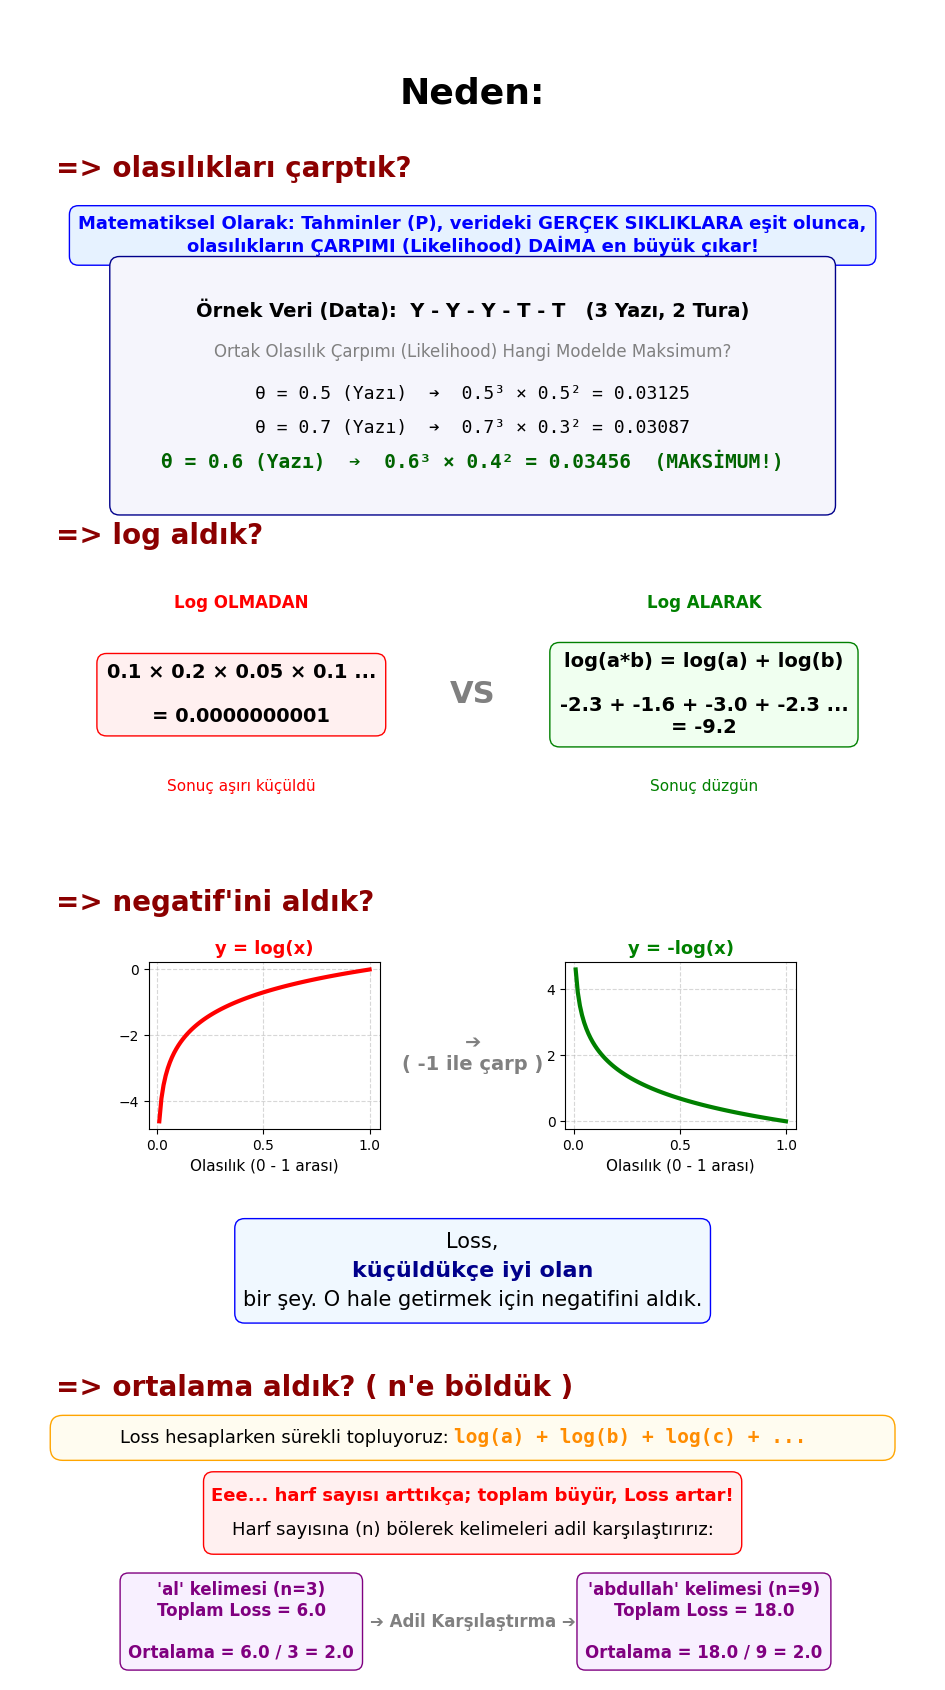

In [6]:
# görselleştirme

# ---------------- NLL (NEGATİF LOG LIKELIHOOD) NEDENLERİ İNFOGRAFİĞİ ----------------
import matplotlib.pyplot as plt
import numpy as np

# Yüksekliği 17 olarak koruyoruz
plt.figure(figsize=(10, 17))
ax = plt.gca()

# ----------------- BAŞLIK -----------------
plt.text(5, 16.5, "Neden:", ha='center', va='center', fontsize=26, fontweight='bold', color='black')

# ----------------- 1. OLASILIKLARI ÇARPTIK? (SENİN BOZUK PARA ÖRNEĞİN!) -----------------
plt.text(0.5, 15.6, "=> olasılıkları çarptık?", ha='left', va='center', fontsize=20, fontweight='bold', color='darkred')

# Üstteki Açıklama Kutusu (Kural)
plt.text(5, 14.8, "Matematiksel Olarak: Tahminler (P), verideki GERÇEK SIKLIKLARA eşit olunca,\nolasılıkların ÇARPIMI (Likelihood) DAİMA en büyük çıkar!", ha='center', va='center', fontsize=13, fontweight='bold', color='blue',
         bbox=dict(facecolor='#e6f2ff', edgecolor='blue', boxstyle='round,pad=0.5'))

# Alttaki Örnek Kutusu Arka Planı (Genişletildi ve yüksekliği ayarlandı, ASLA TAŞMAZ)
box_str = "                                                                                                                 \n\n\n\n\n\n\n\n\n\n"
plt.text(5, 13.0, box_str, ha='center', va='center', fontsize=14, 
         bbox=dict(facecolor='#f5f5fc', edgecolor='darkblue', boxstyle='round,pad=0.5'))

# Örnek İçeriği (İspat)
plt.text(5, 13.9, "Örnek Veri (Data):  Y - Y - Y - T - T   (3 Yazı, 2 Tura)", ha='center', va='center', fontsize=14, fontweight='bold', color='black')
plt.text(5, 13.4, "Ortak Olasılık Çarpımı (Likelihood) Hangi Modelde Maksimum?", ha='center', va='center', fontsize=12, color='gray')

plt.text(5, 12.9, "θ = 0.5 (Yazı)  ➔  0.5³ × 0.5² = 0.03125", ha='center', va='center', fontsize=13, fontfamily='monospace')
plt.text(5, 12.5, "θ = 0.7 (Yazı)  ➔  0.7³ × 0.3² = 0.03087", ha='center', va='center', fontsize=13, fontfamily='monospace')
plt.text(5, 12.1, "θ = 0.6 (Yazı)  ➔  0.6³ × 0.4² = 0.03456  (MAKSİMUM!)", ha='center', va='center', fontsize=14, fontweight='bold', color='darkgreen', fontfamily='monospace')


# ----------------- 2. LOG NEDEN? -----------------
plt.text(0.5, 11.2, "=> log aldık?", ha='left', va='center', fontsize=20, fontweight='bold', color='darkred')

# Log Almadan (Çarpma)
plt.text(2.5, 10.4, "Log OLMADAN", ha='center', va='center', fontsize=12, fontweight='bold', color='red')
plt.text(2.5, 9.3, "0.1 × 0.2 × 0.05 × 0.1 ...\n\n= 0.0000000001", ha='center', va='center', fontsize=14, fontweight='bold', 
         bbox=dict(facecolor='#fff0f0', edgecolor='red', boxstyle='round,pad=0.5'))
plt.text(2.5, 8.2, "Sonuç aşırı küçüldü", ha='center', va='center', fontsize=11, color='red')

# Log Alarak (Toplama)
plt.text(7.5, 10.4, "Log ALARAK", ha='center', va='center', fontsize=12, fontweight='bold', color='green')
plt.text(7.5, 9.3, "log(a*b) = log(a) + log(b)\n\n-2.3 + -1.6 + -3.0 + -2.3 ...\n= -9.2", ha='center', va='center', fontsize=14, fontweight='bold', 
         bbox=dict(facecolor='#f0fff0', edgecolor='green', boxstyle='round,pad=0.5'))
plt.text(7.5, 8.2, "Sonuç düzgün", ha='center', va='center', fontsize=11, color='green')

plt.text(5, 9.3, "VS", ha='center', va='center', fontsize=22, fontweight='bold', color='gray')


# ----------------- 3. NEGATİF NEDEN? (GRAFİKLİ ANLATIM) -----------------
plt.text(0.5, 6.8, "=> negatif'ini aldık?", ha='left', va='center', fontsize=20, fontweight='bold', color='darkred')

x_vals = np.linspace(0.01, 1.0, 100)

# Sol Grafik: y = log(x)
ax_log = ax.inset_axes([0.15, 0.33, 0.25, 0.10]) 
y_log = np.log(x_vals)
ax_log.plot(x_vals, y_log, color='red', lw=3)
ax_log.set_title("y = log(x)", fontsize=13, fontweight='bold', color='red')
ax_log.set_xlabel("Olasılık (0 - 1 arası)", fontsize=11)
ax_log.grid(True, linestyle='--', alpha=0.5)
ax_log.set_xticks([0, 0.5, 1.0])
ax_log.set_yticks([-4, -2, 0])

# Sağ Grafik: y = -log(x)
ax_nlog = ax.inset_axes([0.60, 0.33, 0.25, 0.10])
y_nlog = -np.log(x_vals)
ax_nlog.plot(x_vals, y_nlog, color='green', lw=3)
ax_nlog.set_title("y = -log(x)", fontsize=13, fontweight='bold', color='green')
ax_nlog.set_xlabel("Olasılık (0 - 1 arası)", fontsize=11)
ax_nlog.grid(True, linestyle='--', alpha=0.5)
ax_nlog.set_xticks([0, 0.5, 1.0])
ax_nlog.set_yticks([0, 2, 4])

# Ortadaki Geçiş Oku
plt.text(5, 5.0, "➔\n( -1 ile çarp )", ha='center', va='center', fontsize=14, fontweight='bold', color='gray')

# --- ALT AÇIKLAMA (KUSURSUZ HİZALAMA) ---
y_text = 2.4
box_bg = "                                                                         \n\n\n"
plt.text(5, y_text, box_bg, ha='center', va='center', fontsize=14, 
         bbox=dict(facecolor='#f0f8ff', edgecolor='blue', boxstyle='round,pad=0.5'))

plt.text(5, y_text + 0.35, "Loss,", ha='center', va='center', fontsize=15)
plt.text(5, y_text + 0.00, "küçüldükçe iyi olan", ha='center', va='center', fontsize=16, fontweight='bold', color='darkblue')
plt.text(5, y_text - 0.35, "bir şey. O hale getirmek için negatifini aldık.", ha='center', va='center', fontsize=15)


# ----------------- 4. ORTALAMA NEDEN? -----------------
plt.text(0.5, 1.0, "=> ortalama aldık? ( n'e böldük )", ha='left', va='center', fontsize=20, fontweight='bold', color='darkred')

# 1. Satır: Sarı Kutu 
invisible_yellow_bg = "      Loss hesaplarken sürekli topluyoruz: log(a) + log(b) + log(c) + ............      "
plt.text(5, 0.4, invisible_yellow_bg, ha='center', va='center', fontsize=15, color='#fffcf0',
         bbox=dict(facecolor='#fffcf0', edgecolor='orange', boxstyle='round,pad=0.6'))

plt.text(4.8, 0.4, "Loss hesaplarken sürekli topluyoruz: ", ha='right', va='center', fontsize=13)
plt.text(4.8, 0.4, "log(a) + log(b) + log(c) + ...", ha='left', va='center', fontsize=14, fontweight='bold', color='darkorange', fontfamily='monospace')

# 2. Satır: Kırmızı Uyarı Kutusu
y_box = -0.5
box_str = "                                                                                   \n\n"
plt.text(5, y_box, box_str, ha='center', va='center', fontsize=14, 
         bbox=dict(facecolor='#fff0f0', edgecolor='red', boxstyle='round,pad=0.5'))

plt.text(5, y_box + 0.2, "Eee... harf sayısı arttıkça; toplam büyür, Loss artar!", ha='center', va='center', fontsize=13, fontweight='bold', color='red')
plt.text(5, y_box - 0.2, "Harf sayısına (n) bölerek kelimeleri adil karşılaştırırız:", ha='center', va='center', fontsize=13)

# Örnek Kutuları 
plt.text(2.5, -1.8, "'al' kelimesi (n=3)\nToplam Loss = 6.0\n\nOrtalama = 6.0 / 3 = 2.0", ha='center', va='center', fontsize=12, fontweight='bold', color='purple',
         bbox=dict(facecolor='#f8f0ff', edgecolor='purple', boxstyle='round,pad=0.5'))

plt.text(7.5, -1.8, "'abdullah' kelimesi (n=9)\nToplam Loss = 18.0\n\nOrtalama = 18.0 / 9 = 2.0", ha='center', va='center', fontsize=12, fontweight='bold', color='purple',
         bbox=dict(facecolor='#f8f0ff', edgecolor='purple', boxstyle='round,pad=0.5'))

# Alt Ok
plt.text(5, -1.8, "➔ Adil Karşılaştırma ➔", ha='center', va='center', fontsize=12, fontweight='bold', color='gray')


# ----------------- GRAFİK AYARLARI -----------------
plt.axis('off')
plt.xlim(0, 10)
# Y eksenini 17.5'e kadar yükseltmiştik
plt.ylim(-2.5, 17.5)
plt.tight_layout()
plt.show()
# --------------------------------------------------------------------------------


Son Loss: 2.4901


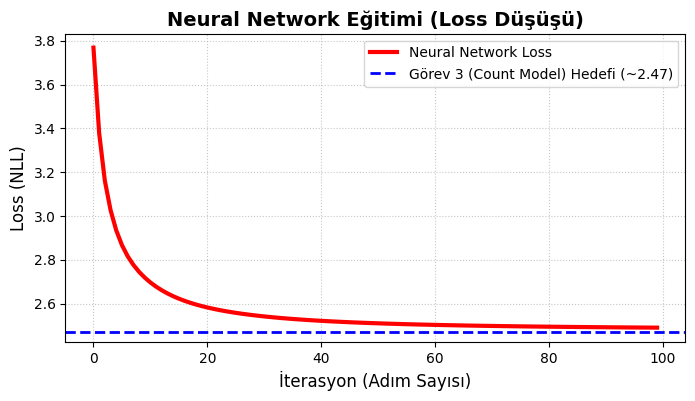

In [ ]:
# Görev 4:
    ## Aynı modeli tek katmanlı sinir ağıyla kur: 
        ### one-hot input
        ### 27x27 weight matrix
        ### softmax
        ### NLL loss
        ### gradient descent döngüsü. 
    ## Loss'un görev 3'teki sayım modelinin loss'una yaklaştığını göster. 
import torch.nn.functional as F
import matplotlib.pyplot as plt


# training set oluştur
xs, ys = [], []
for word in words:
    chs = ['.'] + list(word) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)


# bigram nn modeli eğit
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27,27), generator=g, requires_grad=True)
    ## (27,27) çünkü 27 output var 
        ### her bi char'ın olasılığı output

xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()

# ------ LOSS GRAFİĞİ İÇİN LİSTE ------
losses = []

for i in range(100):
    xenc = F.one_hot(xs, num_classes=27).float()
    
    # forward pass
    logits = xenc @ W

    # softmax activation
    counts = logits.exp()
    probs = counts / counts.sum(1, keepdim=True)

    # loss
    loss = -probs[torch.arange(num), ys].log().mean() + 0.01*(W**2).mean()
    # => neden W**2 ?? regularization
        ## önceden sadeece (ilk kısmı) "eğitim setindeki hataları" minimize ediyoduk
        ## şimdi ise, (2. kısımla) "weight"leri minimize ediyoz
            ## => e karesini alınca daha da patlamaz mı? yumuşamak yerine?
            ## bilerek amplify ediyoruz ki, hatalar daha belirgin olsun
            ## weightler daha çok yumuşasın
    
    # O anki loss değerini listeye ekliyoruz
    losses.append(loss.item())

    # backward pass
    W.grad = None # zero_grad()
    loss.backward()

    # update 
    W.data += -50 * W.grad

print(f"Son Loss: {loss.item():.4f}")

# ================= GRAFİK ÇİZİMİ =================
plt.figure(figsize=(8, 4))
plt.plot(losses, color='red', linewidth=3, label="Neural Network Loss")
plt.axhline(y=2.47, color='blue', linestyle='--', linewidth=2, label="Görev 3 (Count Model) Hedefi (~2.47)")

plt.title("Neural Network Eğitimi (Loss Düşüşü)", fontsize=14, fontweight='bold')
plt.xlabel("İterasyon (Adım Sayısı)", fontsize=12)
plt.ylabel("Loss (NLL)", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.show()
# =================================================


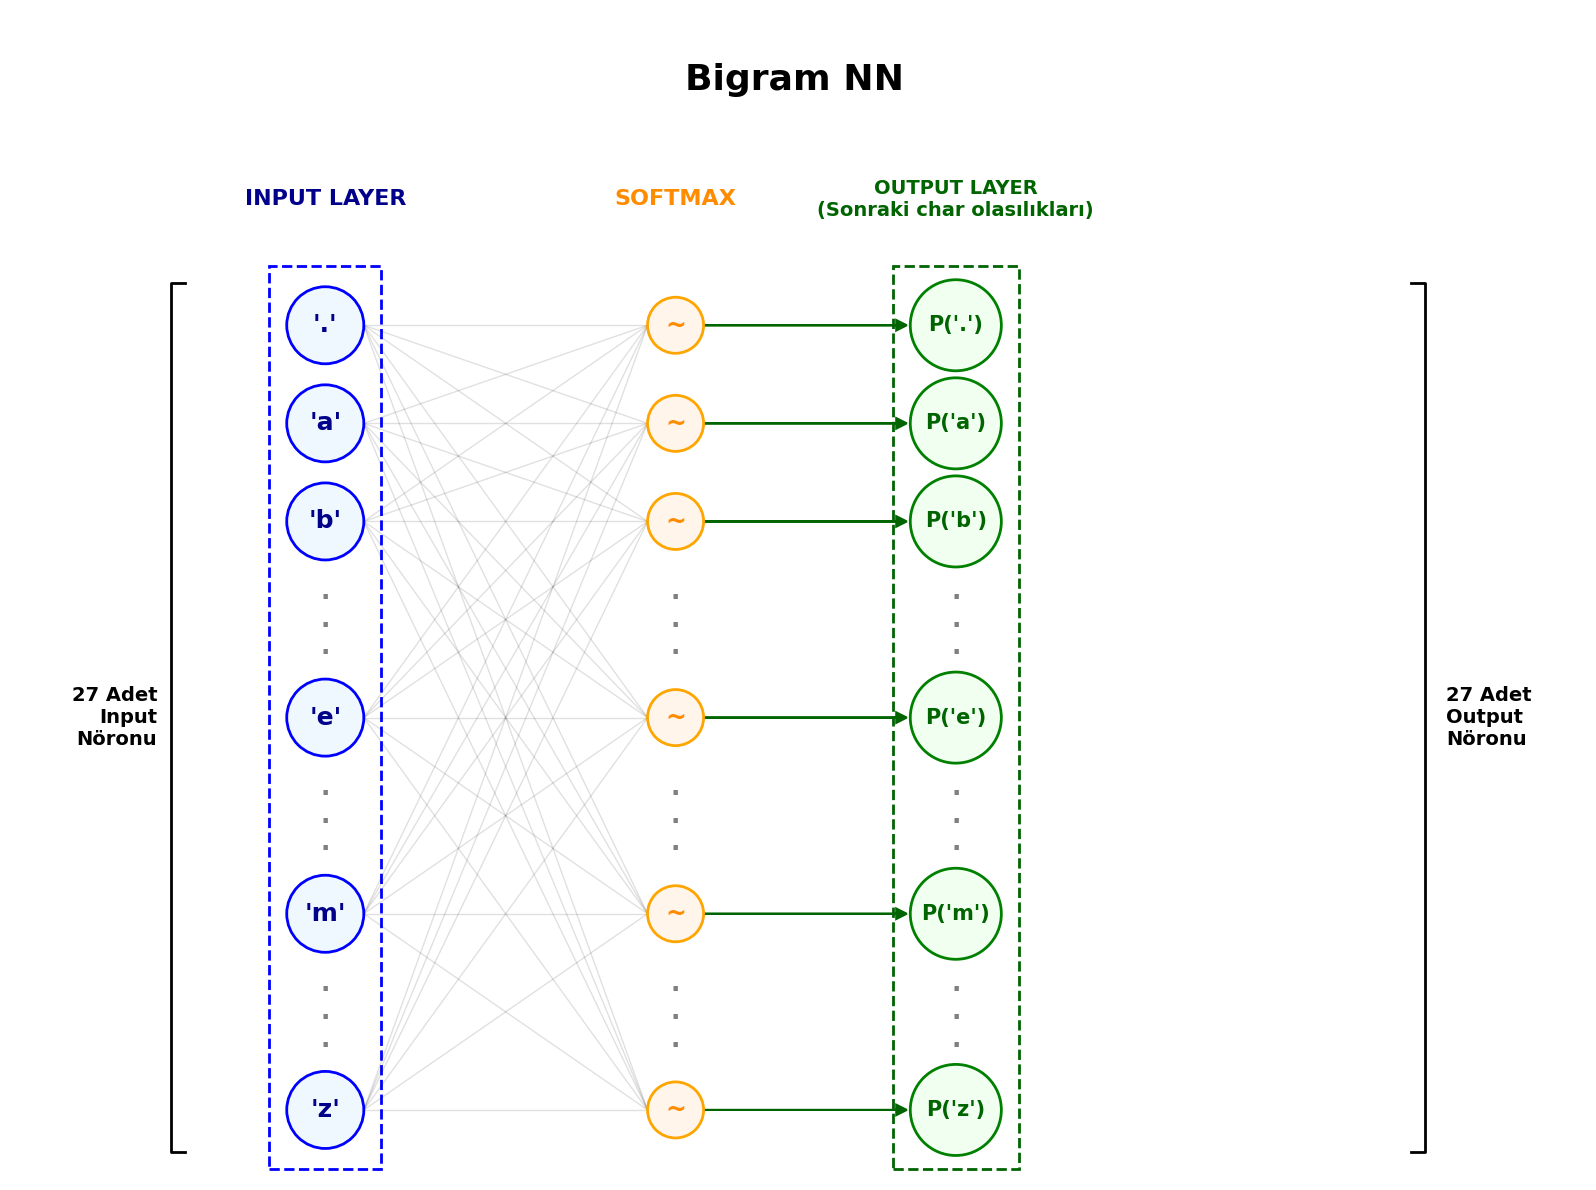

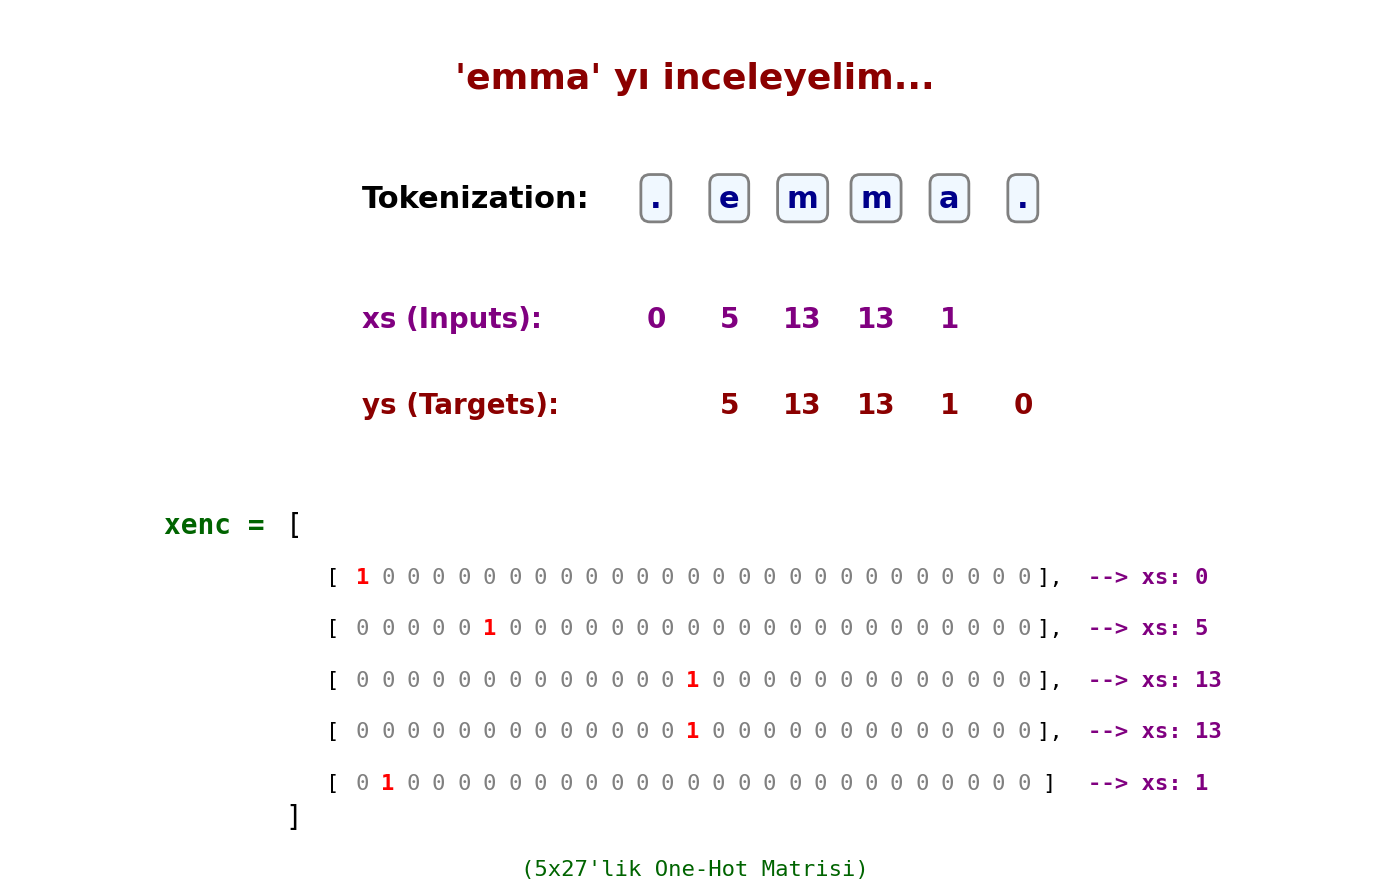

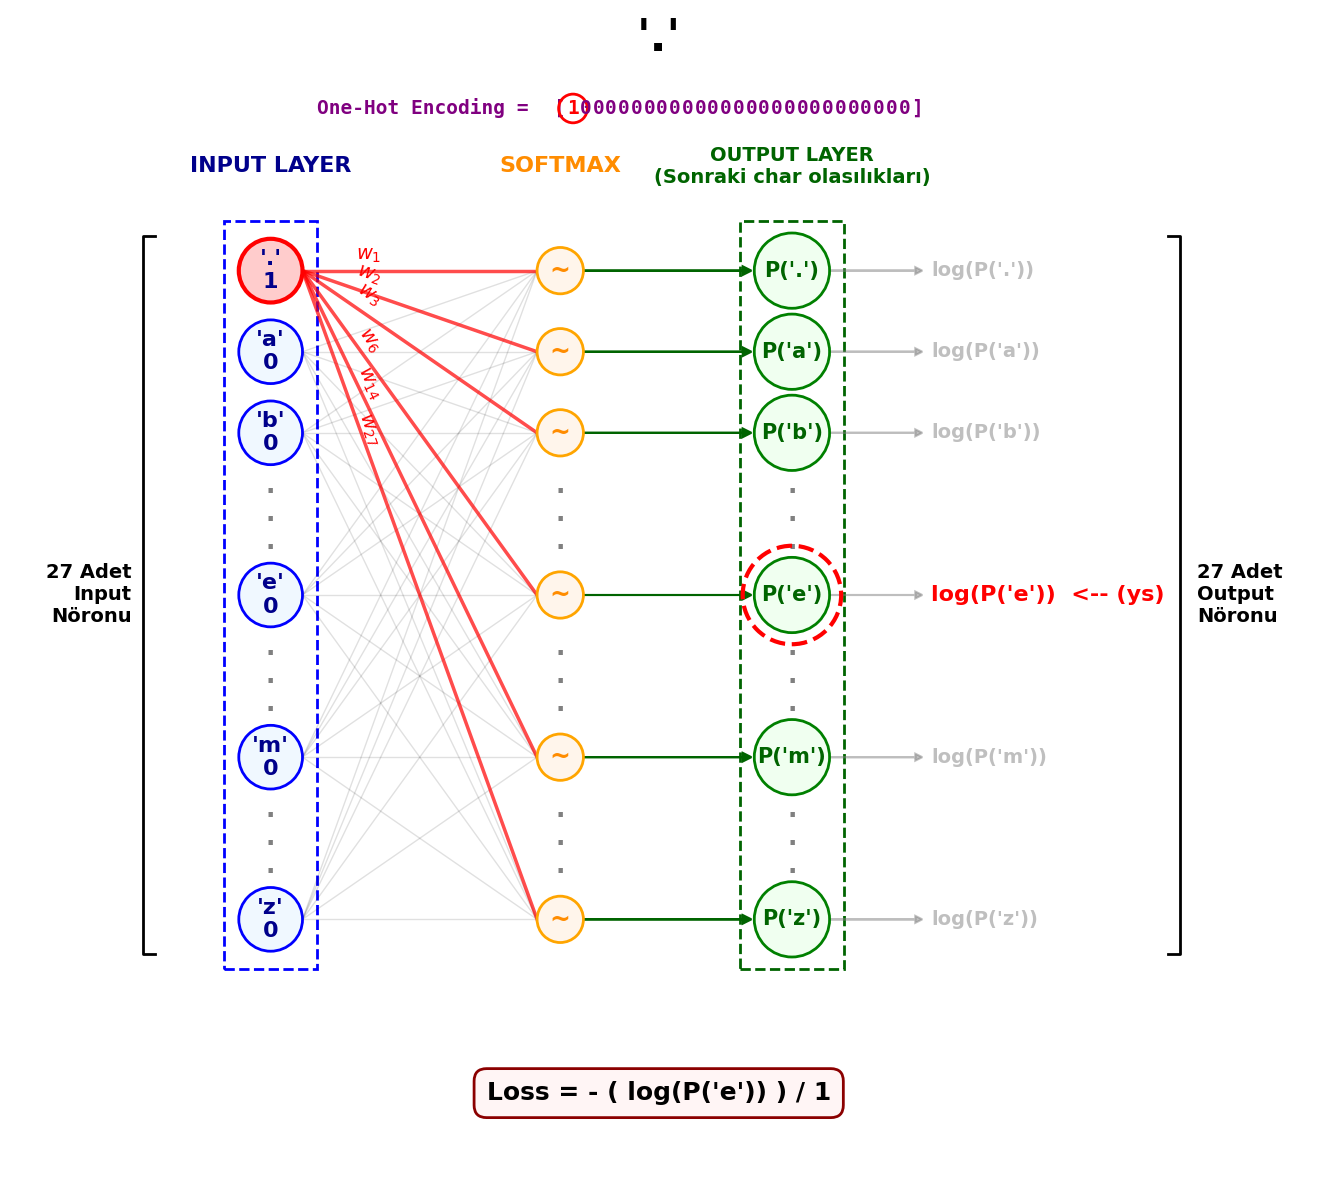

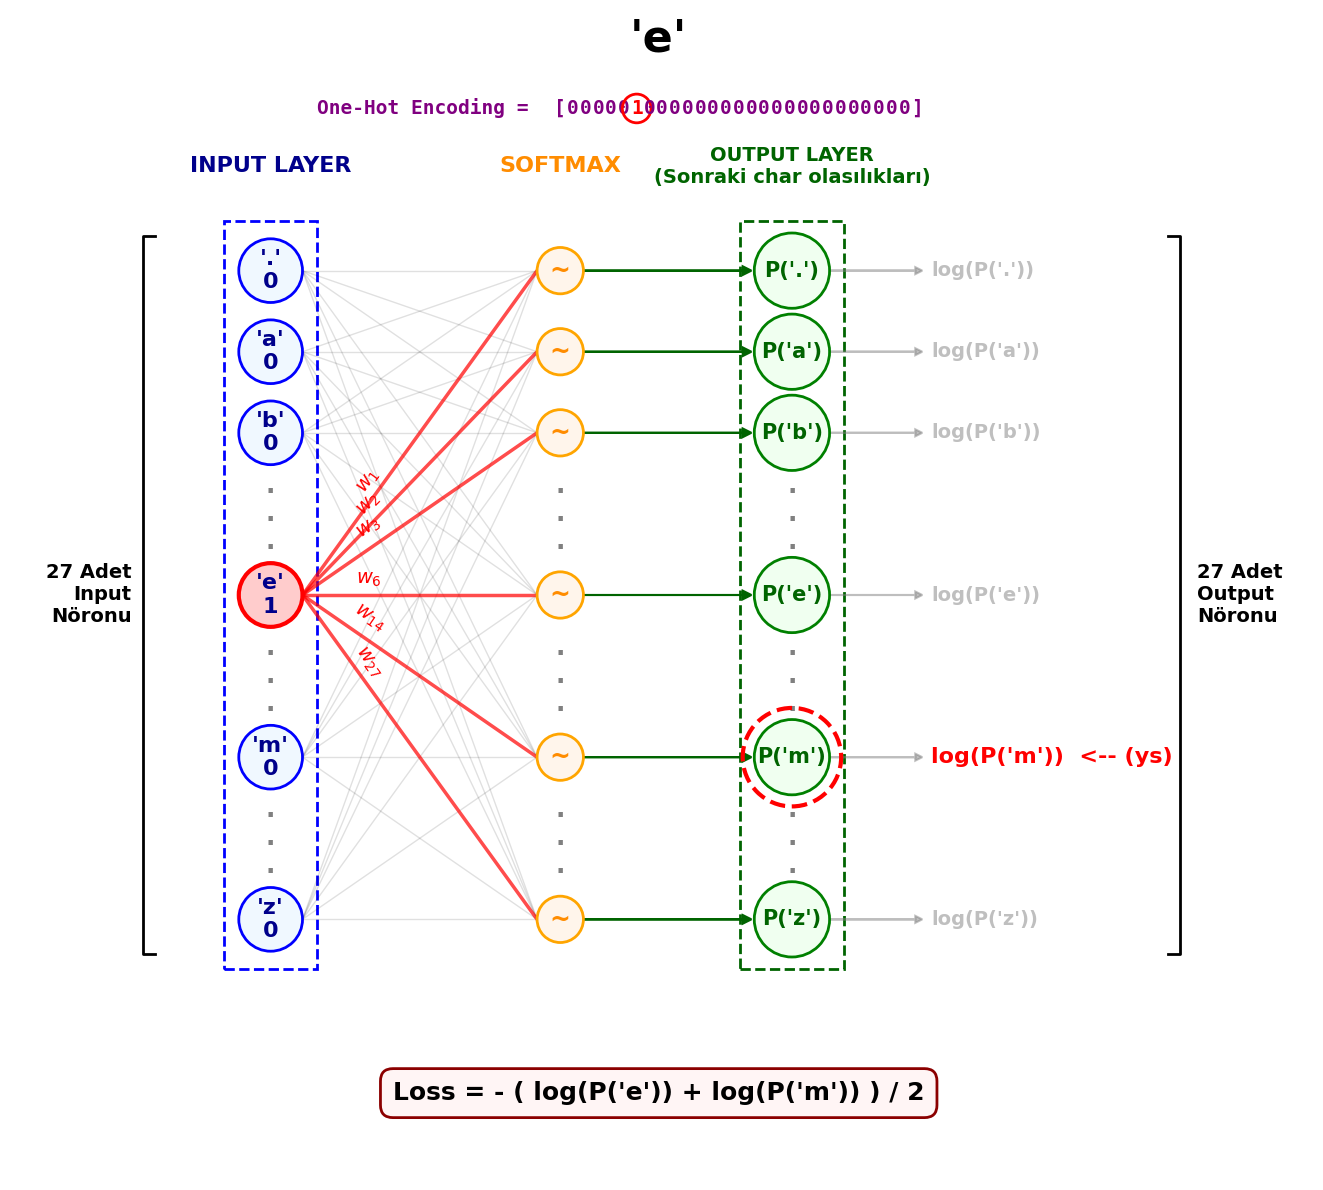

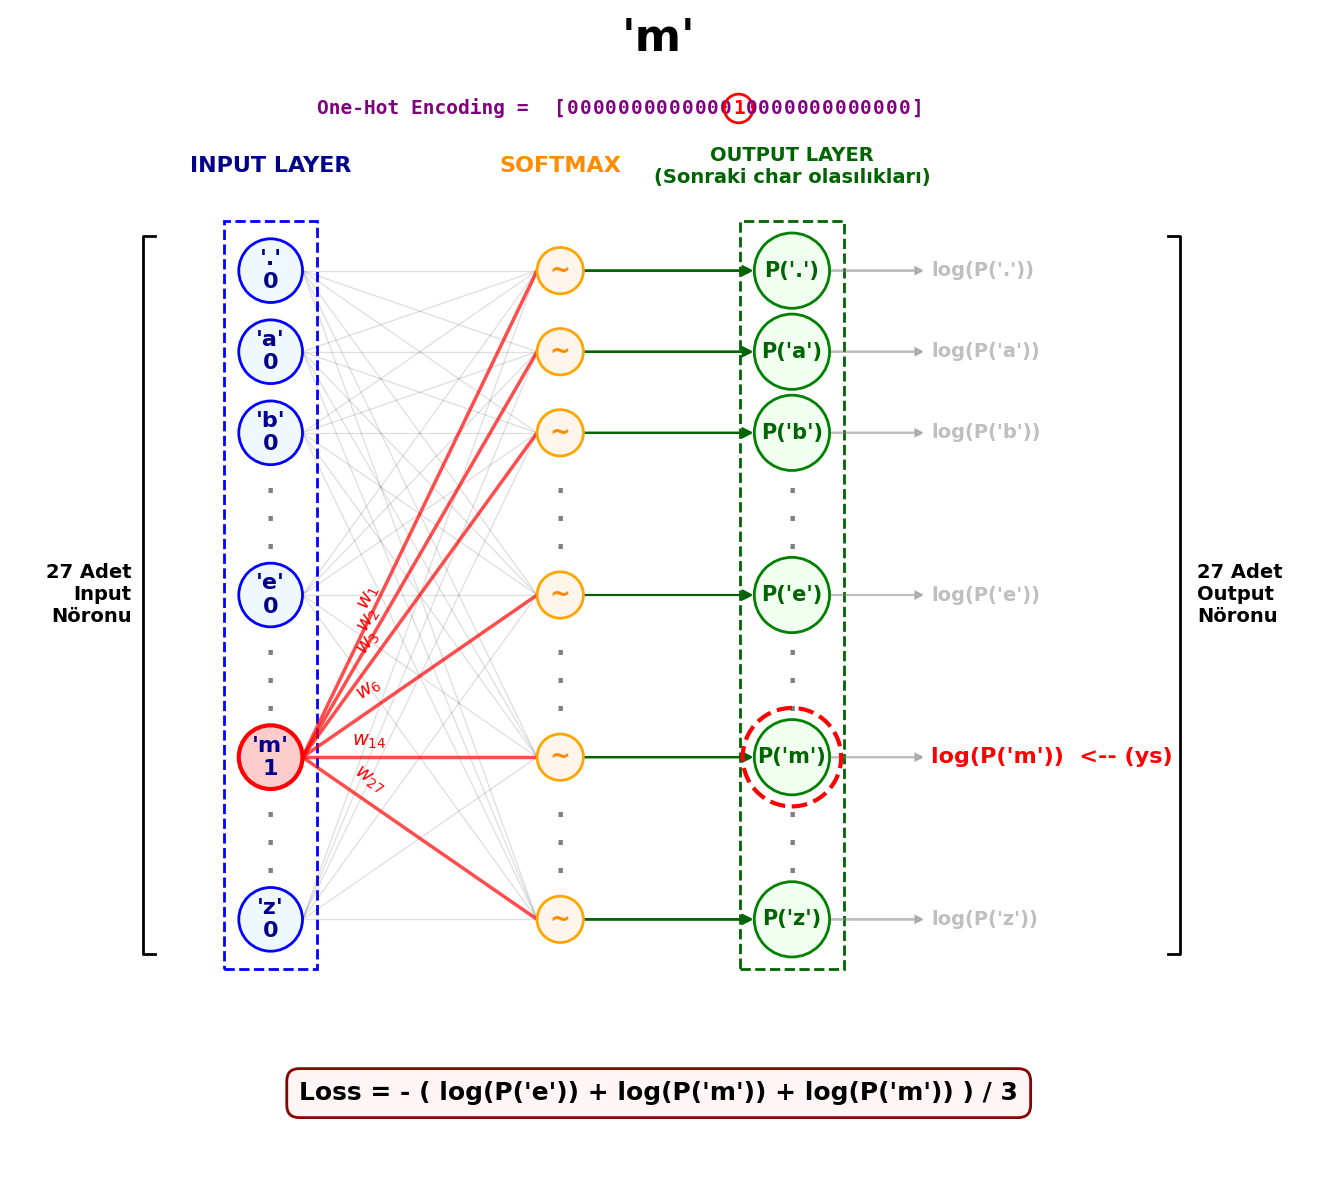

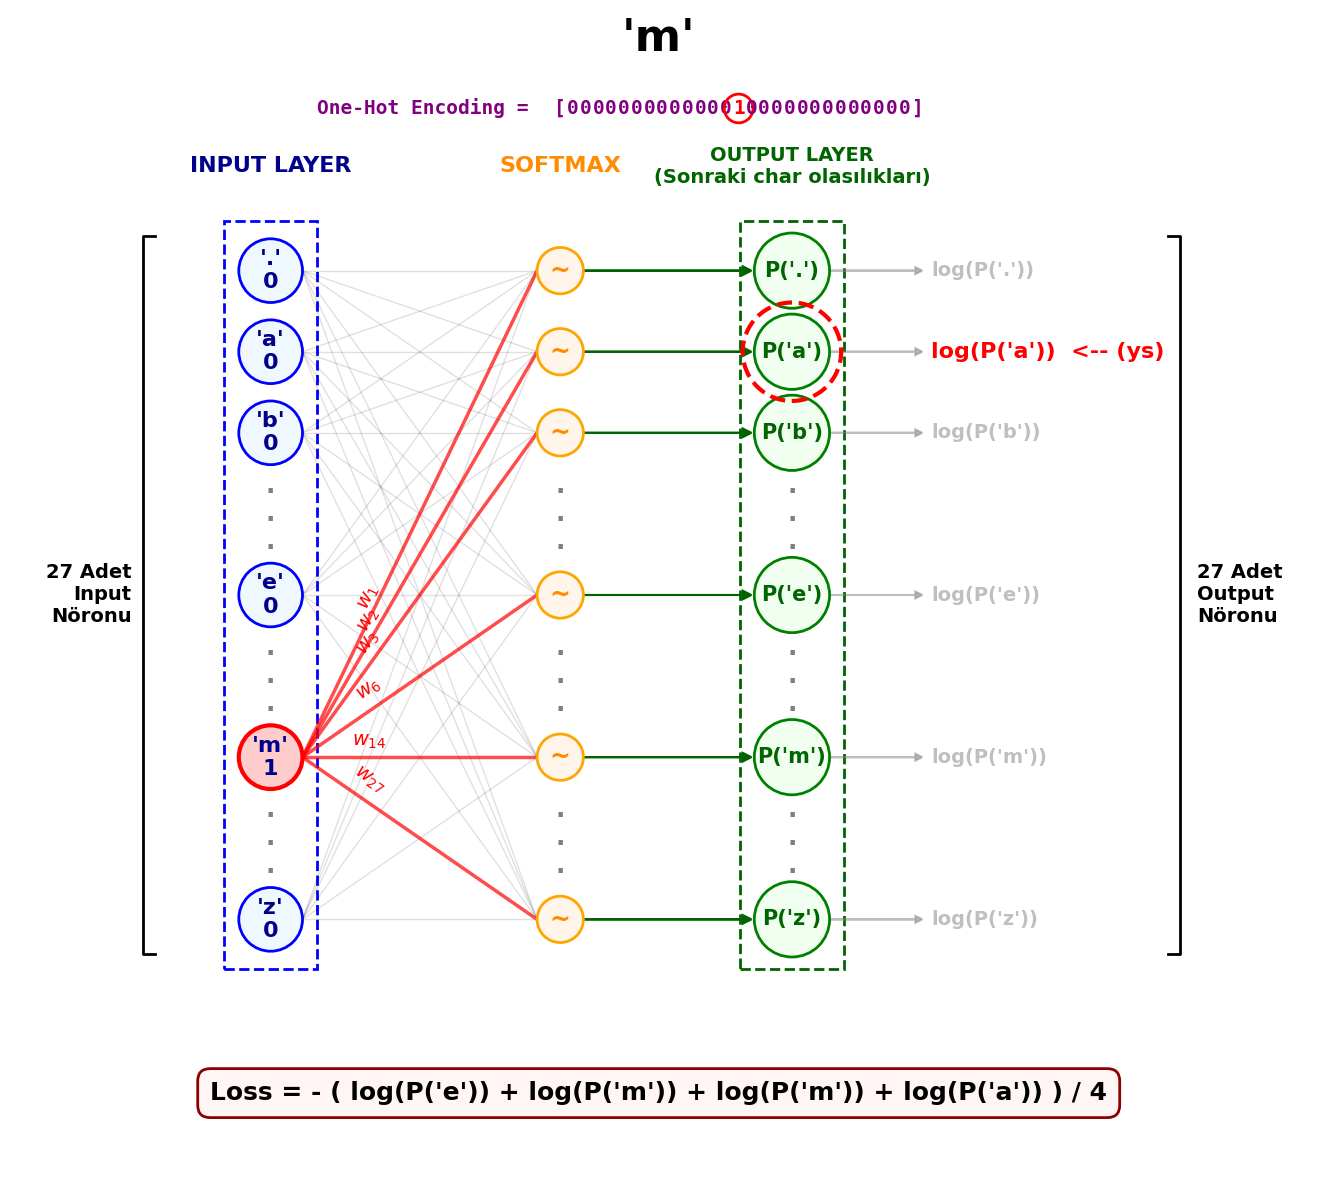

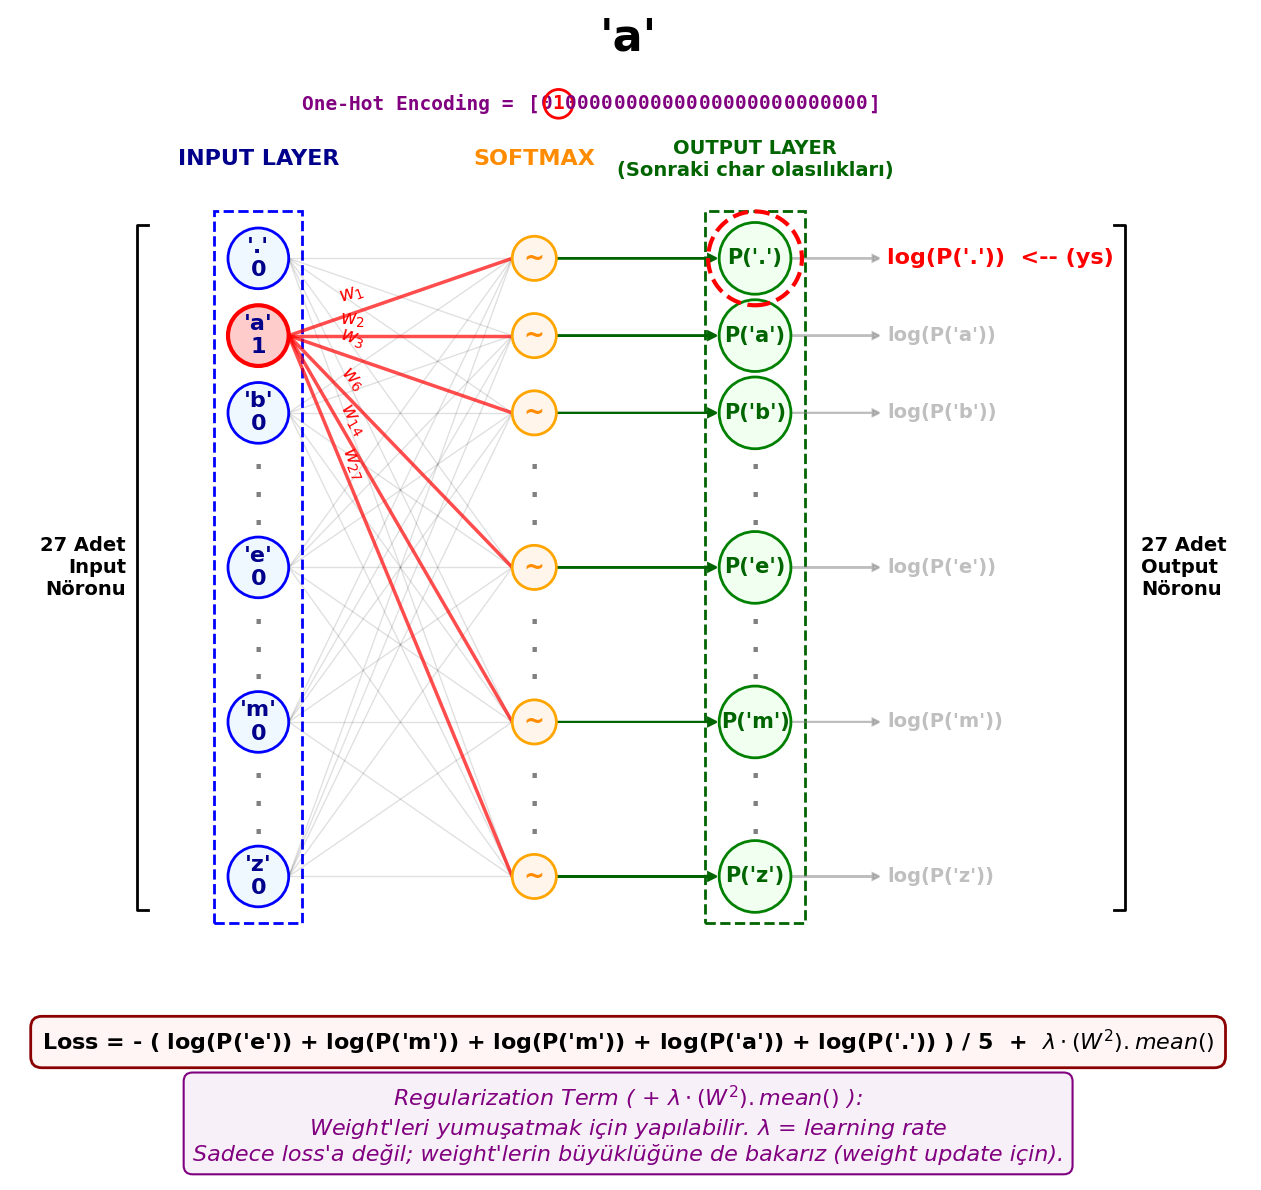

In [9]:
# görselleştirme
# ---------------- BİGRAM SİNİR AĞI MİMARİSİ (NEURAL NETWORK ARCHITECTURE) ----------------
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import math

def draw_network_step(active_char=None, target_char=None, step_num=None, history_targets=None):
    fig, ax = plt.subplots(figsize=(18, 12))
    ax.set_aspect('equal')

    display_nodes = [
        (0, '.'), (1, 'a'), (2, 'b'), (None, '...'),
        (5, 'e'), (None, '...'),
        (13, 'm'), (None, '...'),
        (26, 'z')
    ]
    
    is_neutral = (active_char is None)
    center_x = 9.2
    
    if not is_neutral:
        active_idx = [n[0] for n in display_nodes if n[1] == active_char][0]
        
        oh_array = ["0"] * 27
        oh_array[active_idx] = "1"

        plt.text(center_x, 10.0, f"'{active_char}'", ha='center', va='center', fontsize=32, fontweight='bold')
        
        start_x = 3.3
        plt.text(start_x, 8.8, "One-Hot Encoding =", ha='left', va='center', fontsize=14, fontfamily='monospace', color='purple', fontweight='bold')
        
        current_x = start_x + 4.2 
        plt.text(current_x, 8.8, "[", ha='center', va='center', fontsize=14, fontfamily='monospace', color='purple', fontweight='bold')
        current_x += 0.22
        
        for i, val in enumerate(oh_array):
            if val == "1":
                plt.text(current_x, 8.8, "1", ha='center', va='center', fontsize=14, fontfamily='monospace', color='red', fontweight='bold', 
                         bbox=dict(boxstyle="circle,pad=0.25", ec="red", fc="none", lw=2))
            else:
                plt.text(current_x, 8.8, "0", ha='center', va='center', fontsize=14, fontfamily='monospace', color='purple', fontweight='bold')
            current_x += 0.22  
        
        plt.text(current_x, 8.8, "]", ha='center', va='center', fontsize=14, fontfamily='monospace', color='purple', fontweight='bold')
    else:
        plt.text(center_x, 9.5, "Bigram NN", ha='center', va='center', fontsize=26, fontweight='bold')

    x_in = 2.5
    x_act = 7.5
    x_out = 11.5

    plt.text(x_in, 7.8, "INPUT LAYER", ha='center', va='center', fontsize=16, fontweight='bold', color='darkblue')
    plt.text(x_act, 7.8, "SOFTMAX", ha='center', va='center', fontsize=16, fontweight='bold', color='darkorange')
    plt.text(x_out, 7.8, "OUTPUT LAYER\n(Sonraki char olasılıkları)", ha='center', va='center', fontsize=14, fontweight='bold', color='darkgreen')

    y_start = 6.0
    y_step = 1.4
    
    nodes = []
    current_y = y_start
    for idx, char in display_nodes:
        nodes.append((idx, char, current_y))
        current_y -= y_step

    min_y = nodes[-1][2]
    max_y = nodes[0][2]

    rect_in = patches.Rectangle((x_in - 0.8, min_y - 0.85), 1.6, (max_y - min_y) + 1.7, 
                                linewidth=2, edgecolor='blue', facecolor='none', linestyle='--', zorder=0)
    ax.add_patch(rect_in)

    rect_out = patches.Rectangle((x_out - 0.9, min_y - 0.85), 1.8, (max_y - min_y) + 1.7, 
                                 linewidth=2, edgecolor='darkgreen', facecolor='none', linestyle='--', zorder=0)
    ax.add_patch(rect_out)

    for idx, char, y in nodes:
        if idx is not None:
            is_active = (not is_neutral) and (char == active_char)
            ec_color = "red" if is_active else "blue"
            fc_color = "#ffcccc" if is_active else "#f0f8ff"
            lw_val = 3 if is_active else 2
            
            circle = patches.Circle((x_in, y), 0.55, ec=ec_color, fc=fc_color, lw=lw_val, zorder=3)
            ax.add_patch(circle)
            
            if is_neutral:
                plt.text(x_in, y, f"'{char}'", ha='center', va='center', fontsize=18, fontweight='bold', color='darkblue')
            else:
                val_text = "1" if is_active else "0"
                plt.text(x_in, y, f"'{char}'\n{val_text}", ha='center', va='center', fontsize=16, fontweight='bold', color='darkblue')
        else:
            plt.text(x_in, y, ".\n.\n.", ha='center', va='center', fontsize=18, fontweight='bold', color='gray')

    for idx1, char1, y1 in nodes:
        if idx1 is not None and (is_neutral or char1 != active_char):
            for idx2, char2, y2 in nodes:
                if idx2 is not None:
                    ax.plot([x_in+0.55, x_act-0.4], [y1, y2], color='black', alpha=0.12, linewidth=1.0, zorder=1)

    if not is_neutral:
        for idx1, char1, y1 in nodes:
            if idx1 is not None and char1 == active_char:
                for idx2, char2, y2 in nodes:
                    if idx2 is not None:
                        ax.plot([x_in+0.55, x_act-0.4], [y1, y2], color='red', alpha=0.7, linewidth=2.5, zorder=2)
                        
                        lbl_x = 4.2
                        ratio = (lbl_x - (x_in+0.55)) / ((x_act-0.4) - (x_in+0.55))
                        lbl_y = y1 + ratio * (y2 - y1)
                        angle = math.degrees(math.atan2(y2 - y1, (x_act-0.4) - (x_in+0.55)))
                        weight_label = f"$w_{{{idx2 + 1}}}$"
                        plt.text(lbl_x, lbl_y + 0.1, weight_label, ha='center', va='bottom', 
                                 fontsize=14, fontweight='bold', color='red', rotation=angle, zorder=5)

    for idx, char, y in nodes:
        if idx is not None:
            circle = patches.Circle((x_act, y), 0.4, ec="orange", fc="#fff5eb", lw=2, zorder=3)
            ax.add_patch(circle)
            plt.text(x_act, y, "~", ha='center', va='center', fontsize=18, fontweight='bold', color='darkorange', zorder=4)
            ax.arrow(x_act+0.4, y, (x_out-0.65) - (x_act+0.4) - 0.05, 0, 
                     head_width=0.15, head_length=0.15, fc='darkgreen', ec='darkgreen', lw=1.5, length_includes_head=True)
        else:
            plt.text(x_act, y, ".\n.\n.", ha='center', va='center', fontsize=18, fontweight='bold', color='gray')

    # 4. OUTPUT LAYER
    for idx, char, y in nodes:
        if idx is not None:
            circle = patches.Circle((x_out, y), 0.65, ec="green", fc="#f0fff0", lw=2, zorder=3)
            ax.add_patch(circle)
            plt.text(x_out, y, f"P('{char}')", ha='center', va='center', fontsize=15, fontweight='bold', color='darkgreen')
            
            if not is_neutral:
                arrow_len = 1.6
                ax.arrow(x_out+0.65, y, arrow_len, 0, head_width=0.12, head_length=0.12, fc='gray', ec='gray', lw=1.5, length_includes_head=True, alpha=0.5)
                
                text_x = x_out + 0.65 + arrow_len + 0.15
                
                if char == target_char:
                    plt.text(text_x, y, f"log(P('{char}'))  <-- (ys)", ha='left', va='center', fontsize=16, fontweight='bold', color='red')
                    highlight = patches.Circle((x_out, y), 0.85, ec="red", fc="none", lw=3, linestyle='--', zorder=4)
                    ax.add_patch(highlight)
                else:
                    plt.text(text_x, y, f"log(P('{char}'))", ha='left', va='center', fontsize=14, fontweight='bold', color='gray', alpha=0.5)
        else:
            plt.text(x_out, y, ".\n.\n.", ha='center', va='center', fontsize=18, fontweight='bold', color='gray')

    ax.plot([0.5, 0.3, 0.3, 0.5], [min_y - 0.6, min_y - 0.6, max_y + 0.6, max_y + 0.6], color='black', lw=2)
    plt.text(0.1, (min_y + max_y)/2, "27 Adet\nInput\nNöronu", ha='right', va='center', fontsize=14, fontweight='bold')

    ax.plot([18.0, 18.2, 18.2, 18.0], [min_y - 0.6, min_y - 0.6, max_y + 0.6, max_y + 0.6], color='black', lw=2)
    plt.text(18.5, (min_y + max_y)/2, "27 Adet\nOutput\nNöronu", ha='left', va='center', fontsize=14, fontweight='bold')

    # LOSS HESAPLAMA METNİ 
    if not is_neutral and history_targets is not None:
        loss_terms = [f"log(P('{t}'))" for t in history_targets]
        loss_sum_str = " + ".join(loss_terms)
        n = len(history_targets)
        
        loss_text = f"Loss = - ( {loss_sum_str} ) / {n}"
        loss_fontsize = 18 
        
        if step_num == 5:
            loss_text += r"  +  $\lambda \cdot (W^2).mean()$"
            loss_fontsize = 16 
        
        loss_y_title = min_y - 2.0
        loss_y_box = min_y - 3.0
        
        # ---> İŞTE BURADA: "Adım X:" YAZISI OLMADAN EKLENMİŞ BAŞLIK <---
        
        plt.text(center_x, loss_y_box, loss_text, ha='center', va='center', fontsize=loss_fontsize, fontweight='bold', color='black', 
                 bbox=dict(boxstyle="round,pad=0.5", ec="darkred", fc="#fff5f5", lw=2))
        
        if step_num == 5:
            exp_text = ("Regularization Term ( + $\lambda \cdot (W^2).mean()$ ):\n"
                        "Weight'leri yumuşatmak için yapılabilir. $\lambda$ = learning rate\n"
                        "Sadece loss'a değil; weight'lerin büyüklüğüne de bakarız (weight update için).")
            plt.text(center_x, min_y - 4.5, exp_text, ha='center', va='center', fontsize=16, fontstyle='italic', color='purple',
                     bbox=dict(boxstyle="round,pad=0.4", ec="purple", fc="#f8f0f8", lw=1.5))
            plt.ylim(min_y - 5.5, max_y + 4.5)
        else:
            plt.ylim(min_y - 4.5, max_y + 4.5)
            
    else:
        plt.ylim(min_y - 1.0, max_y + 4.5)

    plt.axis('off')
    plt.xlim(-2.0, 20.5) 
    plt.tight_layout()
    plt.show()

# =========================================================================================
# ========================= ÇİZİMLERİN (HİKAYENİN) OLUŞTURULMASI ==========================
# =========================================================================================

draw_network_step(active_char=None)

fig, ax = plt.subplots(figsize=(14, 9))
ax.set_xlim(0, 14)
ax.set_ylim(0, 10)
ax.axis('off')

plt.text(7, 9.2, "'emma' yı inceleyelim...", ha='center', va='center', fontsize=26, fontweight='bold', color='darkred')

start_x = 3.6
plt.text(start_x, 7.8, "Tokenization:", ha='left', va='center', fontsize=22, fontweight='bold', color='black')
current_x = start_x + 3.0
chars = ['.', 'e', 'm', 'm', 'a', '.']
for char in chars:
    plt.text(current_x, 7.8, char, ha='center', va='center', fontsize=22, fontweight='bold', color='darkblue', 
             bbox=dict(boxstyle="round,pad=0.3", ec="gray", fc="#f0f8ff", lw=2))
    current_x += 0.75

plt.text(start_x, 6.4, "xs (Inputs):", ha='left', va='center', fontsize=20, fontweight='bold', color='purple')
xs_list = [0, 5, 13, 13, 1]
current_x = start_x + 3.0
for val in xs_list:
    plt.text(current_x, 6.4, str(val), ha='center', va='center', fontsize=20, fontweight='bold', color='purple')
    current_x += 0.75

plt.text(start_x, 5.4, "ys (Targets):", ha='left', va='center', fontsize=20, fontweight='bold', color='darkred')
ys_vals = [5, 13, 13, 1, 0]
current_x = start_x + 3.0 + 0.75 
for val in ys_vals:
    plt.text(current_x, 5.4, str(val), ha='center', va='center', fontsize=20, fontweight='bold', color='darkred')
    current_x += 0.75

plt.text(2.6, 4.0, "xenc =", ha='right', va='center', fontsize=20, fontfamily='monospace', color='darkgreen', fontweight='bold')
plt.text(2.9, 4.0, "[", ha='center', va='center', fontsize=20, fontfamily='monospace', color='black')

current_y = 3.4
for row_idx, active_idx in enumerate(xs_list):
    plt.text(3.3, current_y, "[", ha='center', va='center', fontsize=16, fontfamily='monospace', color='black')
    curr_x = 3.6
    for i in range(27):
        if i == active_idx:
            plt.text(curr_x, current_y, "1", ha='center', va='center', fontsize=16, fontfamily='monospace', color='red', fontweight='bold')
        else:
            plt.text(curr_x, current_y, "0", ha='center', va='center', fontsize=16, fontfamily='monospace', color='gray')
        curr_x += 0.26
        
    comma = "," if row_idx < 4 else ""
    plt.text(curr_x, current_y, f"]{comma}", ha='center', va='center', fontsize=16, fontfamily='monospace', color='black')
    plt.text(curr_x + 0.4, current_y, f"--> xs: {active_idx}", ha='left', va='center', fontsize=16, fontfamily='monospace', color='purple', fontweight='bold')
    current_y -= 0.6

plt.text(2.9, current_y + 0.2, "]", ha='center', va='center', fontsize=20, fontfamily='monospace', color='black')
plt.text(7, current_y - 0.4, "(5x27'lik One-Hot Matrisi)", ha='center', va='center', fontsize=16, fontfamily='monospace', color='darkgreen')

plt.tight_layout()
plt.show()

# 3. Aşama: "emma"nın her bir adımı için ağın durumunu çizdirme
word = "emma"
inputs = ['.'] + list(word)
targets = list(word) + ['.'] 

history = []
for step_num, (char_in, char_out) in enumerate(zip(inputs, targets), 1):
    history.append(char_out)
    draw_network_step(active_char=char_in, target_char=char_out, step_num=step_num, history_targets=history)


In [ ]:
# Yaptığım hatalar

# görev 1:
    # chs = "<S>" + list(word) + "<E>" yapmak  --  ["<S>"] ve ["<E>"] olmalıydı

    # python dictionary için yaparken, in words yerine in words[:3] demek (tüm array'i taramamak)

# görev 4:
    ## her char için olasılık tahmin ettik ya
    ## tüüm hepsini toplıcaz sandım
    ## aslında, sadece "sonraki (doğru) label"ınkileri toplıcaz

    # "W = torch.randn((27,27), generator=g, requires_grad=True)"
        ## requires_grad yazmayı unuttum
        ## randn() yerine rand() kullandım
    
    # (W^2).mean() yerine (W^2).sum() dedim





In [7]:
import pandas as pd
import os

def tr_upper_series(col):
    """Pandas Series içindeki küçük 'i' ve 'ı' harflerini bozmadan büyütür"""
    return col.astype(str).str.replace('i', 'İ').str.replace('ı', 'I').str.upper()

def normalize_tr_to_ascii(text):
    """İsimleri İngilizce karakterlere dönüştürerek köklerini bulmak için"""
    if pd.isna(text): return text
    text = str(text).upper()
    for k, v in {'Ç': 'C', 'Ğ': 'G', 'İ': 'I', 'Ö': 'O', 'Ş': 'S', 'Ü': 'U'}.items():
        text = text.replace(k, v)
    return text

def turkish_score(text):
    """İçindeki Türkçe karakter sayısını bulur"""
    tr_chars = set('ÇĞİÖŞÜ')
    return sum(1 for char in str(text) if char in tr_chars)

def clean_series(series):
    """Sayı içeren, 1 harfli olan veya geçersiz (nan) verileri acımadan temizler"""
    series = series.astype(str).str.strip()
    series = series[series.str.len() > 1] # Tek harfleri uçur (A, B, C...)
    series = series[~series.str.contains(r'\d', na=False)] # Sayıları uçur
    invalid = ['nan', 'none', 'null', '']
    series = series[~series.str.lower().isin(invalid)]
    return series

def tr_lower(col):
    """En son ekrana yazdırırken Türkçe küçük harfe çevirmek için"""
    return col.str.replace('I', 'ı').str.replace('İ', 'i').str.lower()

# 1. DOSYALARI OKUMA (Kvtoraman HARİÇ)
base_dir = r'C:\Users\ardah\OneDrive\Masaüstü\yazılım\ML\projects\yz50\hafta-3\data\raw'

dfs = {
    'female': pd.read_csv(os.path.join(base_dir, 'turkishnames', 'female_name_tally'), sep=r'\s+', header=None, names=['name', 'count']),
    'male': pd.read_csv(os.path.join(base_dir, 'turkishnames', 'male_name_tally'), sep=r'\s+', header=None, names=['name', 'count']),
    'tr_erkek': pd.read_csv(os.path.join(base_dir, 'tr_isim_erkek.txt'), sep=',', header=None, names=['name', 'count']),
    'emrekgn': pd.read_csv(os.path.join(base_dir, 'emrekgn.txt'), header=None, names=['name'])
}
dfs['emrekgn']['count'] = 0 # Count'u olmayanlara 0 ekliyoruz

# 2. TEMİZLEME VE BÜYÜTME İŞLEMLERİ
for name, df in dfs.items():
    df['name'] = clean_series(df['name'])
    df.dropna(subset=['name'], inplace=True)
    df['name'] = tr_upper_series(df['name'])

# Güvenilir Referans Listemiz (KVTORAMAN HARİÇ, sadece EMREKGN)
whitelist_names = set(dfs['emrekgn']['name'])

# 3. TOPLAM COUNT HESAPLAMA
variant_counts = {}
for name, df in dfs.items():
    if 'count' in df.columns and name != 'emrekgn':
        for _, row in df.iterrows():
            variant_counts[row['name']] = variant_counts.get(row['name'], 0) + row['count']

all_unique_names = set(list(variant_counts.keys()) + list(whitelist_names))

# 4. İSİMLERİ AYNI KÖKTE BİRLEŞTİRME
base_to_variants = {}
for name in all_unique_names:
    base = normalize_tr_to_ascii(name)
    if base not in base_to_variants: base_to_variants[base] = []
    base_to_variants[base].append(name)

# 5. KUSURSUZ MANTIK: En Doğru Formu Seçme
best_variant_map = {}
for base, variants in base_to_variants.items():
    variants_in_wl = [v for v in variants if v in whitelist_names]
    
    if variants_in_wl:
        best_variant = max(variants_in_wl, key=lambda v: (turkish_score(v), variant_counts.get(v, 0)))
    else:
        best_variant = max(variants, key=lambda v: variant_counts.get(v, 0))
        
    for variant in variants:
        best_variant_map[variant] = best_variant

# 6. TÜM DATAFRAME'LERDEKİ İSİMLERİ GÜNCEL FORMLA DEĞİŞTİR
for name, df in dfs.items():
    df['name'] = df['name'].map(best_variant_map)
    dfs[name] = df.groupby('name', as_index=False)['count'].sum()

# 7. LİMİTLERE GÖRE FİLTRELEME
dfs['female'] = dfs['female'][dfs['female']["count"] >= 1305]
dfs['male'] = dfs['male'][dfs['male']["count"] >= 490]
# Not: Eğer tr_erkek için de minimum bir limit (örn: >= 5) koymak istersen buraya satır ekleyebilirsin.

# 8. KÜÇÜK HARFE ÇEVİRME VE BİRLEŞTİRME
all_names = pd.concat([df['name'] for df in dfs.values()], ignore_index=True)
final_names = all_names.dropna().drop_duplicates()
final_names = tr_lower(final_names).sort_values().reset_index(drop=True)

# 9. DOSYAYA KAYDETME
save_path = os.path.join(base_dir, 'turkish_names_final.txt')
final_names.to_csv(save_path, index=False, header=False, encoding='utf-8')

print(f"✅ 'kvtoraman' HARİÇ tutularak oluşturulan saf veri seti kaydedildi!")
print(f"👉 Dosya Yolu: {save_path}")
print(f"📊 Toplam Benzersiz İsim Sayısı: {len(final_names)}")


✅ 'kvtoraman' HARİÇ tutularak oluşturulan saf veri seti kaydedildi!
👉 Dosya Yolu: C:\Users\ardah\OneDrive\Masaüstü\yazılım\ML\projects\yz50\hafta-3\data\raw\turkish_names_final.txt
📊 Toplam Benzersiz İsim Sayısı: 78801


In [7]:
# Görev 5:
    # İnternetten bir Türkçe isim listesi bul
    # İki modeli de bu veriyle tekrar koştur. 
        # Alfabeyi Türkçe karakterlerle genişlet (ç, ğ, ı, ö, ş, ü)
        # Modelin ürettiği isimlerden örnekleri ve loss'u göster.

# repo linkleri: 
    ## https://github.com/eoner/turkce_isimler/blob/master/tr_isim_erkek.csv
    ## https://github.com/mkozturk/turkishnames/blob/master/turkishnames.zip
    ## https://gist.github.com/kvtoraman/f300ae077828c6940d96cd3b19181b3f
    ## https://gist.github.com/emrekgn/b4049851c88e328c065a



# hazırlık
import torch
import torch.nn.functional as F

def load_words():
    return open('data/preprocessed/turkish_names_final.txt', 'r', encoding='utf-8').read().splitlines()

def get_all_chars(words):
    return sorted(list(set(''.join(words))))

def get_char_count(words):
    all_chars = get_all_chars(words)
    char_count = len(all_chars)

    return char_count + 1



def init_N(words):
    char_count = get_char_count(words)

    N = torch.zeros(char_count, char_count)
    return N

def init_mappings(words):
    all_chars = get_all_chars(words)

    stoi = {s: i+1 for i, s in enumerate(all_chars)}
    stoi['.'] = 0
    itos = {i: s for s, i in stoi.items()}
    return stoi, itos

def init_chars(word):
    chars = ['.'] + list(word) + ['.']
    return chars

def init_g():
    g = torch.Generator().manual_seed(2147483647)
    return g

def init_W(words, g):
    char_count = get_char_count(words)

    W = torch.randn((char_count,char_count), generator=g, requires_grad=True)
    return W

def init_train_set(words):
    xs, ys = [], []

    for word in words:
        chars = init_chars(word)

        for ch1, ch2 in zip(chars, chars[1:]):
            idx1 = get_idx(ch1)
            idx2 = get_idx(ch2)

            xs.append(idx1)
            ys.append(idx2)

    return torch.tensor(xs), torch.tensor(ys)

def init_log_likelihood():
    return 0

def init_n():
    return 0

def init_loss():
    return torch.tensor(0.0)


def fill_N(words):
    for word in words:
        chars = init_chars(word)

        for char1, char2 in zip(chars, chars[1:]):
            idx1 = get_idx(char1)
            idx2 = get_idx(char2)

            N[idx1, idx2] += 1
    return N

def fill_P(N):
    P = (N+1).float()
    P = P / P.sum(axis=1,keepdim=True)
    return P



def get_idx(char):
    idx = stoi[char]
    return idx

def get_char(idx):
    char = itos[idx]
    return char

def get_one_hot_code_encoding(words):
    xenc = F.one_hot(xs, num_classes=get_char_count(words)).float()
    return xenc

def get_log(num):
    return torch.log(num)

def get_probs(idx):
    p = P[idx]
    return p

def get_prob(idx1, idx2):
    p = P[idx1, idx2]
    return p

def get_sample(p,g):
    idx = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    return itos[idx]


def update_log_likelihood(log_likelihood, logprob):
    return log_likelihood + logprob
    
def update_n(n):
    return n+1


words = load_words()

N = init_N(words)
stoi, itos = init_mappings(words)
g = init_g()
xs, ys = init_train_set(words)


N = fill_N(words)
P = fill_P(N)


# Model 1 - Count-based Bigram
def example_generations():
    out = []

    for i in range(5): # 5 tane yeni kelime üretir
        chars = []
        idx = 0 
        
        # her bir kelime generation 
        while True:
            # tahmin ürettik
            p = get_probs(idx)        
            sampled_char = get_sample(p, g) 
            
            # tahmin edilen char kaydettik
            chars.append(sampled_char)
            idx = get_idx(sampled_char)  
            
            # kelime bitmişse çık
            if sampled_char == '.':
                break
                
        out.append(''.join(chars[:-1])) 

    print(out)

def find_loss_count_bigram():
    n = init_n()
    log_likelihood = init_log_likelihood()
    loss = init_loss()

    for idx1, idx2 in zip(xs, ys):

        prob = get_prob(idx1, idx2)
        logprob = get_log(prob)
        log_likelihood = update_log_likelihood(log_likelihood, logprob)

        n = update_n(n)

    loss = -log_likelihood / n
    return loss.item()

example_generations()
find_loss_count_bigram()


# Model 2 - Bigram NN
W = init_W(words, g)
xenc = get_one_hot_code_encoding(words)

n = init_n()
log_likelihood = init_log_likelihood()
loss = init_loss()


# Model 2 - Bigram NN
W = init_W(words, g)
xenc = get_one_hot_code_encoding(words)
num_examples = xs.nelement() # Toplam bigram sayısı



def forward_pass(xenc, W):
    def _linear_transformation(xenc, W):
        # x * W
        logits = xenc @ W
        return logits
    def _activation_func(logits):
        # softmax 
        counts = logits.exp()
        probs = counts / counts.sum(1, keepdims=True)
        return probs

    logits = _linear_transformation(xenc, W) 
    outputs = _activation_func(logits)

    return outputs

def backprop(W,loss):
    W.grad = None
    loss.backward()

    W.data += -50 * W.grad

def get_target_outputs(probs, ys):
    num_examples = probs.shape[0]
    return probs[torch.arange(num_examples), ys]

def update_loss(target_outputs):
    return -target_outputs.log().mean()

for i in range(100):
    # 1. FORWARD PASS
    outputs = forward_pass(xenc, W)

    target_outputs = get_target_outputs(probs, ys)
    
    # Bütün olasılıkların logaritmasını alıp ortalamasını eksiyle çarpıyoruz (İşte Loss!)
    loss = update_loss(target_outputs)
    
    print(f"Epoch {i}: {loss.item()}")

    # 2. BACKWARD PASS
    backprop(W, loss)

    

print(loss.item())

['casran', 'moksl', 'sate', 'aerdduhimur', 'zaculık']
Epoch 0: 14.972579002380371


RuntimeError: Trying to backward through the graph a second time (or directly access saved tensors after they have already been freed). Saved intermediate values of the graph are freed when you call .backward() or autograd.grad(). Specify retain_graph=True if you need to backward through the graph a second time or if you need to access saved tensors after calling backward.

In [11]:
words = open('data/preprocessed/turkish_names_final.txt', 'r', encoding='utf-8').read().splitlines()

chars = sorted(list(set(''.join(words))))
len(chars)

29

In [ ]:
# (Ek) Görev 6: 
    # Modeli trigram'a çevir 
        # (iki önceki harfe bak)
    # veriyi train/dev/test olarak %80/%10/%10 böl
    # smoothing gücünü dev loss'una göre ayarla
    # Bigram ile trigram loss'unu karşılaştır
    # Ürettiği isimlerin nasıl değiştiğini göster. 